In [47]:
# =============================================================================
# STEP 1: IMPORT LIBRARIES AND CONFIGURATION
# =============================================================================

# --- Core Data Processing ---
import pandas as pd
import numpy as np
import warnings
import re

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-Learn: Preprocessing & Model Selection ---
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# --- Scikit-Learn: Models ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# --- Scikit-Learn: Metrics ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Model Persistence ---
import joblib

# --- Statistical Functions ---
from scipy import stats

# --- Suppress Warnings for Clean Output ---
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================

# File path
DATA_PATH = r"H:\City_Deals_Agency.csv"

# Constants
RANDOM_STATE = 42
TEST_SIZE = 0.20
CURRENT_YEAR = 2025

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("✅ Libraries imported and configuration set.")

✅ Libraries imported and configuration set.


In [48]:
# =============================================================================
# STEP 2: DATA CLEANING — UNIT CONVERSIONS & OUTLIER REMOVAL
# =============================================================================

# ---------------------------------------------------------------------------
# 2.1  Remove listings with prices in Arab (extreme outliers)
# ---------------------------------------------------------------------------
print("=" * 60)
print("PHASE 2: DATA CLEANING — CONVERSIONS & FILTERING")
print("=" * 60)

initial_rows = raw_df.shape[0]

# Rows where Price contains 'Arab' are treated as extreme outliers & dropped
df = raw_df[~raw_df['Price'].str.contains('Arab', na=False)].copy()
rows_removed = initial_rows - df.shape[0]
print(f"🗑️  Removed {rows_removed} listings with 'Arab'-denominated prices (outliers)")
print(f"   Remaining records: {df.shape[0]:,}")

# ---------------------------------------------------------------------------
# 2.2  Helper: convert Area (Marla / Kanal) → Square Feet
# ---------------------------------------------------------------------------
def area_to_square_feet(area_str):
    """
    Convert a property area string to square feet.
    Supports 'Marla' (× 272.25) and 'Kanal' (× 5445).
    Returns NaN for unparseable or missing values.
    """
    if pd.isna(area_str) or not isinstance(area_str, str):
        return np.nan

    area_str = area_str.strip()

    if 'Marla' in area_str:
        try:
            return float(area_str.split()[0]) * 272.25
        except (ValueError, IndexError):
            return np.nan

    if 'Kanal' in area_str:
        try:
            return float(area_str.split()[0]) * 5445
        except (ValueError, IndexError):
            return np.nan

    return np.nan


# ---------------------------------------------------------------------------
# 2.3  Helper: convert Price (Crore / Lakh) → PKR
# ---------------------------------------------------------------------------
def price_to_pkr(price_str):
    """
    Convert a property price string to PKR (integer).
    Supports 'Crore' (× 10⁷) and 'Lakh' (× 10⁵).
    Returns NaN for unparseable or missing values.
    """
    if pd.isna(price_str) or not isinstance(price_str, str):
        return np.nan

    price_str = price_str.strip()

    if 'Crore' in price_str:
        try:
            return float(price_str.replace('Crore', '').strip()) * 10_000_000
        except ValueError:
            return np.nan

    if 'Lakh' in price_str:
        try:
            return float(price_str.replace('Lakh', '').strip()) * 100_000
        except ValueError:
            return np.nan

    return np.nan


# ---------------------------------------------------------------------------
# 2.4  Apply conversions and create new numeric columns
# ---------------------------------------------------------------------------
df['Area_SqFt']  = df['Area'].apply(area_to_square_feet)
df['Price_PKR']  = df['Price'].apply(price_to_pkr)

print(f"\n✅ Area & Price columns converted:")
print(f"   → 'Area_SqFt' (square feet)")
print(f"   → 'Price_PKR' (Pakistani Rupees)")

print(f"\n📊 Sample converted values (first 3 rows):")
for i in range(3):
    orig_area   = df['Area'].iloc[i]
    conv_area   = df['Area_SqFt'].iloc[i]
    orig_price  = df['Price'].iloc[i]
    conv_price  = df['Price_PKR'].iloc[i]
    print(f"   Row {i}:  Area = '{orig_area}' → {conv_area:,.0f} sqft  |  "
          f"Price = '{orig_price}' → PKR {conv_price:,.0f}")

print("\n" + "=" * 60)
print("Phase-2 Complete: Unit conversions applied & outlier rows removed.\n")

PHASE 2: DATA CLEANING — CONVERSIONS & FILTERING
🗑️  Removed 10 listings with 'Arab'-denominated prices (outliers)
   Remaining records: 18,239

✅ Area & Price columns converted:
   → 'Area_SqFt' (square feet)
   → 'Price_PKR' (Pakistani Rupees)

📊 Sample converted values (first 3 rows):
   Row 0:  Area = '1 Kanal' → 5,445 sqft  |  Price = '8.15 Crore' → PKR 81,500,000
   Row 1:  Area = '5 Marla' → 1,361 sqft  |  Price = '1.5 Crore' → PKR 15,000,000
   Row 2:  Area = '5 Marla' → 1,361 sqft  |  Price = '2.4 Crore' → PKR 24,000,000

Phase-2 Complete: Unit conversions applied & outlier rows removed.



In [49]:
# =============================================================================
# STEP 3: REMOVE ROWS WITH MISSING AREA OR PRICE
# =============================================================================
# Target and the key feature cannot be missing — drop those rows.
# =============================================================================

print("=" * 60)
print("PHASE 3: HANDLING MISSING VALUES — AREA & PRICE")
print("=" * 60)

# --- 3.1  Inspect missing counts for the two critical columns ---
missing_area  = df['Area_SqFt'].isna().sum()
missing_price = df['Price_PKR'].isna().sum()

print(f"🔍 Missing values detected:")
print(f"   → Area_SqFt : {missing_area:>5} rows")
print(f"   → Price_PKR : {missing_price:>5} rows")

# --- 3.2  Drop rows where either Area or Price is absent ---
rows_before = df.shape[0]
df = df.dropna(subset=['Area_SqFt', 'Price_PKR'])
rows_removed = rows_before - df.shape[0]

print(f"\n🗑️  Removed {rows_removed} rows with missing Area or Price.")
print(f"   Rows before : {rows_before:,}")
print(f"   Rows after  : {df.shape[0]:,}")

print("\n" + "=" * 60)
print("Phase-3 Complete: Dataset now has valid Area & Price for all records.\n")

PHASE 3: HANDLING MISSING VALUES — AREA & PRICE
🔍 Missing values detected:
   → Area_SqFt :     0 rows
   → Price_PKR :     6 rows

🗑️  Removed 6 rows with missing Area or Price.
   Rows before : 18,239
   Rows after  : 18,233

Phase-3 Complete: Dataset now has valid Area & Price for all records.



In [50]:
# =============================================================================
# STEP 4: CLEAN AND STANDARDIZE NUMERIC COLUMNS
# =============================================================================
# Ensure Bedrooms, Bathrooms, Kitchens, and Built Year are numeric,
# remove unrealistic values, and fill missing entries with sensible defaults.
# =============================================================================

print("=" * 60)
print("PHASE 4: NUMERIC COLUMNS — CLEANING & IMPUTATION")
print("=" * 60)


# --------------------------------------------------------------------------
# 4.1  Helper: safely convert a single value to float
# --------------------------------------------------------------------------
def safe_float(value):
    """
    Convert a raw value to float, treating empty strings, dashes,
    and question marks as missing (NaN).
    """
    if pd.isna(value):
        return np.nan

    if isinstance(value, str):
        value = value.strip()
        if value in ('', '-', '?'):
            return np.nan
        try:
            return float(value)
        except ValueError:
            return np.nan

    return float(value)


# --------------------------------------------------------------------------
# 4.2  Clean Bedrooms & Bathrooms (numeric + median imputation)
# --------------------------------------------------------------------------
for col in ['Bedrooms', 'Bathrooms']:
    df[col] = df[col].apply(safe_float)

    missing_count = df[col].isna().sum()
    median_val    = df[col].median()

    df[col] = df[col].fillna(median_val)

    print(f"\n🧹 Column '{col}' cleaned:")
    print(f"    Missing values : {missing_count}")
    print(f"    Filled with median : {median_val:.1f}")


# --------------------------------------------------------------------------
# 4.3  Clean Kitchens
# --------------------------------------------------------------------------
df['Kitchens'] = pd.to_numeric(df['Kitchens'], errors='coerce')
kitchens_median = df['Kitchens'].median()
df['Kitchens'] = df['Kitchens'].fillna(kitchens_median)

print(f"\n🧹 Column 'Kitchens' cleaned:")
print(f"    Filled with median : {kitchens_median:.1f}")


# --------------------------------------------------------------------------
# 4.4  Clean Built Year (realistic range + imputation)
# --------------------------------------------------------------------------
df['Built Year'] = pd.to_numeric(df['Built Year'], errors='coerce')

# Keep only realistic construction years
df = df[(df['Built Year'] >= 1900) & (df['Built Year'] <= 2025)]

# Fill any remaining missing years with a common default (2020)
df['Built Year'] = df['Built Year'].fillna(2020).astype(int)

print(f"\n🧹 Column 'Built Year' cleaned:")
print(f"    Valid range : 1900 – 2025")
print(f"    Unique years (sample) : {sorted(df['Built Year'].unique())[:10]}")


# --------------------------------------------------------------------------
# 4.5  Summary
# --------------------------------------------------------------------------
print(f"\n{'─' * 50}")
print(f"✅ All numeric columns standardized.")
print(f"   Final dataset size : {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\n" + "=" * 60)
print("Phase-4 Complete: Numeric columns are ready for feature engineering.\n")
# =============================================================================
# FLOOR EXTRACTION FUNCTIONS (defined before STEP-5)
# =============================================================================
# These helpers infer the number of floors from the listing title or,
# when the title is not informative, estimate floors from area and bedrooms.
# =============================================================================

import re

# --------------------------------------------------------------------------
# Helper A – extract floors from the listing title
# --------------------------------------------------------------------------
def extract_floors_from_title(title: str):
    """
    Parse the listing title to determine the number of floors.

    Mapping examples:
        "Single Storey"   → 1
        "Double Storey"   → 2
        "Triple Storey"   → 3
        "1.5 Storey"      → 2
        "2.5 Storey"      → 3

    Returns np.nan when no pattern is recognised.
    """
    if pd.isna(title):
        return np.nan

    title_lower = str(title).lower()

    # Ordered list of (regex_pattern, floor_count) – first match wins
    patterns = [
        (r'triple\s*(?:storey|story)',       3),
        (r'(?:3|three)\s*(?:storey|story)',  3),
        (r'double\s*(?:storey|story)',       2),
        (r'(?:2|two)\s*(?:storey|story)',    2),
        (r'single\s*(?:storey|story)',       1),
        (r'(?:1|one)\s*(?:storey|story)',    1),
        (r'1\.5\s*(?:storey|story)',         2),
        (r'2\.5\s*(?:storey|story)',         3),
    ]

    for pattern, floors in patterns:
        if re.search(pattern, title_lower):
            return floors

    return np.nan


# --------------------------------------------------------------------------
# Helper B – estimate floors from property size and bedroom count
# --------------------------------------------------------------------------
def derive_floors_from_features(area_sqft: float, bedrooms: int):
    """
    Estimate the likely number of floors when the listing title
    does not mention them explicitly.

    Heuristic:
        • Small plots (≤ 3 Marla)  → need more floors for many bedrooms.
        • Medium plots (≤ 5 Marla) → moderate floor count.
        • Large plots (≥ 10 Marla) → fewer floors needed.
    """
    area_marla = area_sqft / 272.25

    if area_marla <= 3:
        if bedrooms >= 4:
            return 3
        if bedrooms >= 3:
            return 3
        return 2

    if area_marla <= 5:
        if bedrooms >= 6:
            return 3
        if bedrooms >= 5:
            return 2.5
        if bedrooms >= 3:
            return 2
        return 2

    if area_marla <= 10:
        if bedrooms >= 7:
            return 3
        if bedrooms >= 5:
            return 2
        return 2

    if area_marla <= 20:          # ≈ 1 Kanal
        if bedrooms >= 8:
            return 3
        return 2

    # Very large properties default to 2.5 floors
    return 3


print("✅ Floor extraction helper functions defined.\n")

PHASE 4: NUMERIC COLUMNS — CLEANING & IMPUTATION

🧹 Column 'Bedrooms' cleaned:
    Missing values : 318
    Filled with median : 5.0

🧹 Column 'Bathrooms' cleaned:
    Missing values : 418
    Filled with median : 5.0

🧹 Column 'Kitchens' cleaned:
    Filled with median : 2.0

🧹 Column 'Built Year' cleaned:
    Valid range : 1900 – 2025
    Unique years (sample) : [np.int64(1960), np.int64(1975), np.int64(1980), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1990), np.int64(1992), np.int64(1995), np.int64(1996)]

──────────────────────────────────────────────────
✅ All numeric columns standardized.
   Final dataset size : 13,409 rows × 25 columns

Phase-4 Complete: Numeric columns are ready for feature engineering.

✅ Floor extraction helper functions defined.



In [51]:
# =============================================================================
# STEP 5: FEATURE ENGINEERING — NUMBER OF FLOORS
# =============================================================================
# Extract the number of floors from listing titles, derive it where missing,
# and store it as a clean numeric feature for the model.
# =============================================================================

import re

print("\n" + "=" * 60)
print("PHASE 5: FEATURE ENGINEERING — NUMBER OF FLOORS")
print("=" * 60)

# --------------------------------------------------------------------------
# 5.1  Extract explicit floor information from the 'Title' column
# --------------------------------------------------------------------------
COL_TITLE = 'Title'

if COL_TITLE in df.columns:
    df['Num_Floors'] = df[COL_TITLE].apply(extract_floors_from_title)

    extracted_count = df['Num_Floors'].notna().sum()
    total_rows      = len(df)

    print(f"\n📋 Floor info extracted from '{COL_TITLE}' "
          f"({extracted_count} / {total_rows} listings, "
          f"{extracted_count / total_rows:.1%})")

    print("   Extracted distribution:")
    for floors, cnt in df['Num_Floors'].value_counts().sort_index().items():
        print(f"     {floors:>4}  floor(s) : {cnt:>5,}  houses")
else:
    df['Num_Floors'] = np.nan
    print(f"\n⚠️  Column '{COL_TITLE}' not found. "
          "Floors will be estimated from property size & bedrooms.")


# --------------------------------------------------------------------------
# 5.2  Estimate missing floor values from Area + Bedrooms
# --------------------------------------------------------------------------
missing_before = df['Num_Floors'].isna().sum()

if missing_before > 0:
    print(f"\n🔧 Estimating floors for {missing_before} listings "
          f"using area & bedroom count …")

    missing_mask = df['Num_Floors'].isna()
    df.loc[missing_mask, 'Num_Floors'] = df[missing_mask].apply(
        lambda row: derive_floors_from_features(
            row['Area_SqFt'],
            row['Bedrooms']
        ),
        axis=1
    )

    missing_after = df['Num_Floors'].isna().sum()
    print(f"   Remaining missing after estimation : {missing_after}")
else:
    print("\n   ✅ All listings already have floor information.")


# --------------------------------------------------------------------------
# 5.3  Fallback — fill any residual NaNs with the most common value (2)
# --------------------------------------------------------------------------
df['Num_Floors'] = df['Num_Floors'].fillna(2)

# --------------------------------------------------------------------------
# 5.4  Store as integer when all values are whole numbers
# --------------------------------------------------------------------------
if (df['Num_Floors'] % 1 == 0).all():
    df['Num_Floors'] = df['Num_Floors'].astype(int)

# --------------------------------------------------------------------------
# 5.5  Final summary
# --------------------------------------------------------------------------
print(f"\n✅ Final 'Num_Floors' distribution:")
for floors, cnt in df['Num_Floors'].value_counts().sort_index().items():
    bar = '█' * int(cnt / len(df) * 40)          # simple inline bar
    print(f"   {floors:>4}  floor(s) : {cnt:>5,}  houses  {bar}")

print(f"\n   Average floors : {df['Num_Floors'].mean():.2f}")

print("\n" + "=" * 60)
print("Phase-5 Complete: 'Num_Floors' feature engineered & ready.\n")


PHASE 5: FEATURE ENGINEERING — NUMBER OF FLOORS

📋 Floor info extracted from 'Title' (1063 / 13409 listings, 7.9%)
   Extracted distribution:
      1.0  floor(s) :   104  houses
      2.0  floor(s) :   743  houses
      3.0  floor(s) :   216  houses

🔧 Estimating floors for 12346 listings using area & bedroom count …
   Remaining missing after estimation : 0

✅ Final 'Num_Floors' distribution:
    1.0  floor(s) :   104  houses  
    2.0  floor(s) : 11,105  houses  █████████████████████████████████
    2.5  floor(s) :   285  houses  
    3.0  floor(s) : 1,915  houses  █████

   Average floors : 2.15

Phase-5 Complete: 'Num_Floors' feature engineered & ready.



In [52]:
# =============================================================================
# STEP 6: CREATE BINARY AMENITY FEATURES
# =============================================================================
# Convert textual TRUE / FALSE columns into machine-friendly 0 / 1 integers.
# Also ensure servant quarters and store rooms are clean numeric values.
# =============================================================================

print("=" * 60)
print("PHASE 6: FEATURE ENCODING — BINARY AMENITIES")
print("=" * 60)

# --------------------------------------------------------------------------
# 6.1  Define the list of boolean-style amenity columns
# --------------------------------------------------------------------------
BOOLEAN_AMENITY_COLS = [
    'Furnished',
    'Gym',
    'Study Room',
    'Drawing Room',
    'Dining Room',
    'Lawn/Garden',
    'Swimming Pool',
    'Electricity Backup',
    'Lounge/Sitting Room',
]

# --------------------------------------------------------------------------
# 6.2  Convert each boolean column to 0 / 1
# --------------------------------------------------------------------------
for col in BOOLEAN_AMENITY_COLS:
    if col not in df.columns:
        print(f"   ⚠️  Column '{col}' not found — skipping.")
        continue

    # Map 'TRUE' (string or boolean) → 1, everything else → 0
    df[col] = df[col].apply(
        lambda val: 1 if (
            (isinstance(val, str) and val.strip().upper() == 'TRUE') or
            (isinstance(val, bool) and val)
        ) else 0
    )

    print(f"   ✅ '{col}' encoded as binary (0 / 1)")


# --------------------------------------------------------------------------
# 6.3  Clean integer-amenity columns (Servant Quarters, Store Rooms)
# --------------------------------------------------------------------------
INTEGER_AMENITY_COLS = ['Servant Quarters', 'Store Rooms']

for col in INTEGER_AMENITY_COLS:
    if col not in df.columns:
        print(f"   ⚠️  Column '{col}' not found — skipping.")
        continue

    df[col] = pd.to_numeric(df[col], errors='coerce')   # force numeric
    df[col] = df[col].fillna(0).astype(int)              # missing → 0

    print(f"   ✅ '{col}' converted to integer")


print("\n" + "=" * 60)
print("Phase-6 Complete: All amenity features are numeric & ready for modeling.\n")

PHASE 6: FEATURE ENCODING — BINARY AMENITIES
   ✅ 'Furnished' encoded as binary (0 / 1)
   ✅ 'Gym' encoded as binary (0 / 1)
   ✅ 'Study Room' encoded as binary (0 / 1)
   ✅ 'Drawing Room' encoded as binary (0 / 1)
   ✅ 'Dining Room' encoded as binary (0 / 1)
   ✅ 'Lawn/Garden' encoded as binary (0 / 1)
   ✅ 'Swimming Pool' encoded as binary (0 / 1)
   ✅ 'Electricity Backup' encoded as binary (0 / 1)
   ✅ 'Lounge/Sitting Room' encoded as binary (0 / 1)
   ✅ 'Servant Quarters' converted to integer
   ✅ 'Store Rooms' converted to integer

Phase-6 Complete: All amenity features are numeric & ready for modeling.



In [53]:
# =============================================================================
# STEP 7: FEATURE ENGINEERING — DERIVED FEATURES
# =============================================================================
# Create composite / ratio features to help the model capture non-linear
# relationships and better generalise across different property types.
# =============================================================================

print("=" * 60)
print("PHASE 7: FEATURE ENGINEERING — DERIVED FEATURES")
print("=" * 60)

# --------------------------------------------------------------------------
# 7.1  House age (years since construction)
# --------------------------------------------------------------------------
CURRENT_YEAR = 2025
df['House_Age'] = CURRENT_YEAR - df['Built Year']
print(f"   ✅ 'House_Age' created  (ref year = {CURRENT_YEAR})")

# --------------------------------------------------------------------------
# 7.2  Total amenities score (simple count of available facilities)
# --------------------------------------------------------------------------
AMENITY_SUBSET = [
    'Gym', 'Study Room', 'Drawing Room', 'Dining Room',
    'Lawn/Garden', 'Swimming Pool', 'Electricity Backup',
    'Lounge/Sitting Room'
]
df['Total_Amenities'] = df[AMENITY_SUBSET].sum(axis=1)
print(f"   ✅ 'Total_Amenities' created  (sum of {len(AMENITY_SUBSET)} binary flags)")

# --------------------------------------------------------------------------
# 7.3  Simplified main location (keeps cardinality manageable)
# --------------------------------------------------------------------------
def extract_main_location(location_str):
    """Return the last segment of a comma-separated address."""
    if pd.isna(location_str):
        return 'Unknown'
    parts = str(location_str).strip().split(',')
    return parts[-1].strip() if parts else 'Unknown'

df['Main_Location'] = df['Location'].apply(extract_main_location)

# Retain only the most frequent locations; group the rest as 'Other'
TOP_N_LOCATIONS = 15
top_locations = df['Main_Location'].value_counts().nlargest(TOP_N_LOCATIONS).index
df['Main_Location'] = df['Main_Location'].apply(
    lambda loc: loc if loc in top_locations else 'Other'
)
print(f"   ✅ 'Main_Location' simplified — top {TOP_N_LOCATIONS} kept, rest → 'Other'")
print(f"      Sample : {list(top_locations[:5])}")

# --------------------------------------------------------------------------
# 7.4  Corner plot & park-facing flags (parsed from listing title)
# --------------------------------------------------------------------------
TITLE_COL = 'Title'

if TITLE_COL in df.columns:
    df[TITLE_COL] = df[TITLE_COL].fillna('')
    df['Is_Corner']   = df[TITLE_COL].str.contains(
                            'corner', case=False, na=False).astype(int)
    df['Facing_Park'] = df[TITLE_COL].str.contains(
                            'facing park', case=False, na=False).astype(int)
    print(f"   ✅ 'Is_Corner' & 'Facing_Park' parsed from '{TITLE_COL}'")
    print(f"      Corner houses : {df['Is_Corner'].sum():,}")
    print(f"      Park-facing   : {df['Facing_Park'].sum():,}")
else:
    df['Is_Corner']   = 0
    df['Facing_Park'] = 0
    print(f"   ⚠️  '{TITLE_COL}' column missing — corner & park flags set to 0")

# --------------------------------------------------------------------------
# 7.5  Price per square foot
# --------------------------------------------------------------------------
df['Price_per_SqFt'] = df['Price_PKR'] / df['Area_SqFt']
print(f"   ✅ 'Price_per_SqFt' created  (mean = PKR {df['Price_per_SqFt'].mean():,.0f})")

# --------------------------------------------------------------------------
# 7.6  Bathroom‑to‑area ratio
# --------------------------------------------------------------------------
df['Bathroom_Ratio'] = df['Bathrooms'] / df['Area_SqFt']
print(f"   ✅ 'Bathroom_Ratio' created")

# --------------------------------------------------------------------------
# Summary
# --------------------------------------------------------------------------
print(f"\n{'─'*50}")
print(f"✅ Derived features added. Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
print("\n" + "=" * 60)
print("Phase-7 Complete: All engineered features are created.\n")

PHASE 7: FEATURE ENGINEERING — DERIVED FEATURES
   ✅ 'House_Age' created  (ref year = 2025)
   ✅ 'Total_Amenities' created  (sum of 8 binary flags)
   ✅ 'Main_Location' simplified — top 15 kept, rest → 'Other'
      Sample : ['Punjab']
   ✅ 'Is_Corner' & 'Facing_Park' parsed from 'Title'
      Corner houses : 541
      Park-facing   : 273
   ✅ 'Price_per_SqFt' created  (mean = PKR inf)
   ✅ 'Bathroom_Ratio' created

──────────────────────────────────────────────────
✅ Derived features added. Dataset shape: 13,409 rows × 33 cols

Phase-7 Complete: All engineered features are created.



In [54]:
# =============================================================================
# STEP 8: OUTLIER TRIMMING — AREA & PRICE PER SQFT
# =============================================================================
# Clip extreme values in Price_per_SqFt and Area_SqFt at the 1st and
# 99th percentiles to reduce the influence of outliers on the model.
# =============================================================================

print("=" * 60)
print("PHASE 8: OUTLIER TRIMMING")
print("=" * 60)

rows_before = df.shape[0]

# --------------------------------------------------------------------------
# 8.1  Trim Price per Square Foot (top & bottom 1 %)
# --------------------------------------------------------------------------
pps_lower = df['Price_per_SqFt'].quantile(0.01)
pps_upper = df['Price_per_SqFt'].quantile(0.99)

df = df[(df['Price_per_SqFt'] >= pps_lower) & (df['Price_per_SqFt'] <= pps_upper)]

print(f"\n📐 Price_per_SqFt trimming:")
print(f"   Lower bound (1st percentile) : PKR {pps_lower:,.0f}")
print(f"   Upper bound (99th percentile): PKR {pps_upper:,.0f}")
print(f"   Rows after trim : {df.shape[0]:,}")

# --------------------------------------------------------------------------
# 8.2  Trim Area (Square Feet) at the 1st & 99th percentiles
# --------------------------------------------------------------------------
area_lower = df['Area_SqFt'].quantile(0.01)
area_upper = df['Area_SqFt'].quantile(0.99)

df = df[(df['Area_SqFt'] >= area_lower) & (df['Area_SqFt'] <= area_upper)]

print(f"\n📐 Area_SqFt trimming:")
print(f"   Lower bound (1st percentile) : {area_lower:,.0f} sqft")
print(f"   Upper bound (99th percentile): {area_upper:,.0f} sqft")
print(f"   Rows after trim : {df.shape[0]:,}")

# --------------------------------------------------------------------------
# 8.3  Summary
# --------------------------------------------------------------------------
rows_removed = rows_before - df.shape[0]
print(f"\n🗑️  Total rows removed: {rows_removed} ({rows_removed/rows_before:.2%})")
print(f"   Final clean dataset size: {df.shape[0]:,} rows")

print("\n" + "=" * 60)
print("Phase-8 Complete: Outliers trimmed, dataset ready for modeling.\n")

PHASE 8: OUTLIER TRIMMING

📐 Price_per_SqFt trimming:
   Lower bound (1st percentile) : PKR 6,612
   Upper bound (99th percentile): PKR 40,404
   Rows after trim : 13,147

📐 Area_SqFt trimming:
   Lower bound (1st percentile) : 599 sqft
   Upper bound (99th percentile): 10,890 sqft
   Rows after trim : 12,896

🗑️  Total rows removed: 513 (3.83%)
   Final clean dataset size: 12,896 rows

Phase-8 Complete: Outliers trimmed, dataset ready for modeling.



In [55]:
# =============================================================================
# STEP 9: DEFINE FEATURE SET & TARGET VARIABLE
# =============================================================================
# Select the columns that will serve as predictors (X) and the target (y).
# =============================================================================

print("=" * 60)
print("PHASE 9: FEATURE & TARGET SELECTION")
print("=" * 60)

# --------------------------------------------------------------------------
# 9.1  Feature lists
# --------------------------------------------------------------------------
CATEGORICAL_FEATURES = ['Main_Location']

NUMERICAL_FEATURES = [
    'Area_SqFt',
    'Bathrooms',
    'Bedrooms',
    'Kitchens',
    'House_Age',
    'Num_Floors',               # engineered in Phase-5
    'Servant Quarters',
    'Store Rooms',
    'Furnished',
    'Gym',
    'Study Room',
    'Drawing Room',
    'Dining Room',
    'Lawn/Garden',
    'Swimming Pool',
    'Electricity Backup',
    'Lounge/Sitting Room',
    'Total_Amenities',          # composite score (Phase-7)
    'Is_Corner',                # parsed from title (Phase-7)
    'Facing_Park',              # parsed from title (Phase-7)
    'Price_per_SqFt',           # derived ratio (Phase-7)
    'Bathroom_Ratio',           # derived ratio (Phase-7)
]

# Keep only columns that actually exist in the dataframe
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]
NUMERICAL_FEATURES   = [c for c in NUMERICAL_FEATURES   if c in df.columns]

print(f"\n📋 Categorical features ({len(CATEGORICAL_FEATURES)}):")
for col in CATEGORICAL_FEATURES:
    print(f"   • {col}")

print(f"\n📋 Numerical features ({len(NUMERICAL_FEATURES)}):")
for idx, col in enumerate(NUMERICAL_FEATURES, start=1):
    print(f"   {idx:2}. {col}")

# --------------------------------------------------------------------------
# 9.2  Build feature matrix X and target vector y
# --------------------------------------------------------------------------
feature_cols = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

X = df[feature_cols].copy()
y = df['Price_PKR'].copy()

print(f"\n✅ Feature matrix X : {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"✅ Target vector y  : {y.shape[0]:,} values")

print("\n" + "=" * 60)
print("Phase-9 Complete: Features & target ready for train-test split.\n")

PHASE 9: FEATURE & TARGET SELECTION

📋 Categorical features (1):
   • Main_Location

📋 Numerical features (22):
    1. Area_SqFt
    2. Bathrooms
    3. Bedrooms
    4. Kitchens
    5. House_Age
    6. Num_Floors
    7. Servant Quarters
    8. Store Rooms
    9. Furnished
   10. Gym
   11. Study Room
   12. Drawing Room
   13. Dining Room
   14. Lawn/Garden
   15. Swimming Pool
   16. Electricity Backup
   17. Lounge/Sitting Room
   18. Total_Amenities
   19. Is_Corner
   20. Facing_Park
   21. Price_per_SqFt
   22. Bathroom_Ratio

✅ Feature matrix X : 12,896 rows × 23 columns
✅ Target vector y  : 12,896 values

Phase-9 Complete: Features & target ready for train-test split.



In [56]:
# =============================================================================
# STEP 10: FINAL DATA SANITISATION — REMOVE NaN & Inf
# =============================================================================
# Before training, ensure every cell in X is finite and non-null.
# Categorical features receive a placeholder string; numerical features
# are imputed with their median.
# =============================================================================

print("=" * 60)
print("PHASE 10: FINAL SANITISATION — HANDLING NaN / Inf")
print("=" * 60)

# --------------------------------------------------------------------------
# 10.1  Replace infinite values with NaN (so imputers can process them)
# --------------------------------------------------------------------------
X = X.replace([np.inf, -np.inf], np.nan)

# --------------------------------------------------------------------------
# 10.2  Report columns that still contain NaN
# --------------------------------------------------------------------------
nan_summary = X.isna().sum()
nan_cols = nan_summary[nan_summary > 0]

if len(nan_cols) > 0:
    print("\n🔍 Columns with remaining NaN values:")
    for col, cnt in nan_cols.items():
        print(f"   → {col:<25s} : {cnt:>6,}  missing")
else:
    print("\n✅ No NaN values detected in the feature matrix.")

# --------------------------------------------------------------------------
# 10.3  Impute numerical features with their median
# --------------------------------------------------------------------------
for col in NUMERICAL_FEATURES:
    if col not in X.columns:
        continue
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)

# --------------------------------------------------------------------------
# 10.4  Impute categorical features with a placeholder
# --------------------------------------------------------------------------
for col in CATEGORICAL_FEATURES:
    if col not in X.columns:
        continue
    X[col] = X[col].fillna('Unknown')

# --------------------------------------------------------------------------
# 10.5  Final verification
# --------------------------------------------------------------------------
remaining_nan = X.isna().sum().sum()
remaining_inf = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()

print(f"\n🔎 Post‑imputation check:")
print(f"   Remaining NaN : {remaining_nan}")
print(f"   Remaining Inf : {remaining_inf}")

print("\n✅ Data is fully sanitised and ready for modeling.")

print("\n" + "=" * 60)
print("Phase-10 Complete: Feature matrix is clean & finite.\n")

PHASE 10: FINAL SANITISATION — HANDLING NaN / Inf

✅ No NaN values detected in the feature matrix.

🔎 Post‑imputation check:
   Remaining NaN : 0
   Remaining Inf : 0

✅ Data is fully sanitised and ready for modeling.

Phase-10 Complete: Feature matrix is clean & finite.



In [57]:
# =============================================================================
# STEP 11: TRAIN-TEST SPLIT
# =============================================================================
# Partition the dataset into training (80 %) and hold-out test (20 %) sets
# using a fixed random seed for reproducible results.
# =============================================================================

print("=" * 60)
print("PHASE 11: TRAIN-TEST SPLIT")
print("=" * 60)

TEST_SIZE_RATIO = 0.20
RANDOM_STATE    = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size    = TEST_SIZE_RATIO,
    random_state = RANDOM_STATE
)

print(f"\n✅ Data split completed ({1 - TEST_SIZE_RATIO:.0%} train / {TEST_SIZE_RATIO:.0%} test):")
print(f"   Training set : {X_train.shape[0]:,} samples")
print(f"   Test set     : {X_test.shape[0]:,} samples")
print(f"   Features     : {X_train.shape[1]}")

print("\n" + "=" * 60)
print("Phase-11 Complete: Training & test sets ready for modeling.\n")

PHASE 11: TRAIN-TEST SPLIT

✅ Data split completed (80% train / 20% test):
   Training set : 10,316 samples
   Test set     : 2,580 samples
   Features     : 23

Phase-11 Complete: Training & test sets ready for modeling.



In [58]:
# =============================================================================
# STEP 12: BUILD THE PREPROCESSING PIPELINE
# =============================================================================
# Define independent transformers for numerical and categorical features,
# then combine them into a single ColumnTransformer that can be plugged
# into any scikit-learn model.
# =============================================================================

print("=" * 60)
print("PHASE 12: PREPROCESSING PIPELINE")
print("=" * 60)

# --------------------------------------------------------------------------
# 12.1  Numerical pipeline: impute missing values → scale to zero mean / unit variance
# --------------------------------------------------------------------------
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',   StandardScaler())
])

# --------------------------------------------------------------------------
# 12.2  Categorical pipeline: fill missing → one‑hot encode
# --------------------------------------------------------------------------
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --------------------------------------------------------------------------
# 12.3  Combine both transformers using ColumnTransformer
# --------------------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer,   NUMERICAL_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder='drop'   # drop any column not explicitly listed above
)

print("\n✅ Preprocessing pipeline built successfully.")
print(f"   Numerical features : {len(NUMERICAL_FEATURES)}")
print(f"   Categorical features : {len(CATEGORICAL_FEATURES)}")

print("\n" + "=" * 60)
print("Phase-12 Complete: Preprocessor ready to be used with any estimator.\n")

PHASE 12: PREPROCESSING PIPELINE

✅ Preprocessing pipeline built successfully.
   Numerical features : 22
   Categorical features : 1

Phase-12 Complete: Preprocessor ready to be used with any estimator.



In [59]:
# =============================================================================
# STEP 13.5: BASIC LINEAR REGRESSION (FOR COMPARISON)
# =============================================================================
from sklearn.linear_model import LinearRegression

print("\n" + "=" * 60)
print("MODEL 1 : BASIC LINEAR REGRESSION (BASELINE)")
print("=" * 60)

# Create pipeline with basic Linear Regression
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("⏳ Training Basic Linear Regression …")
pipeline_lr.fit(X_train, y_train)

print("🔮 Generating predictions on test set …")
y_pred_lr = pipeline_lr.predict(X_test)

# Evaluate
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\n📊 Basic Linear Regression — Performance on Test Set")
print(f"   • MAE  : PKR {mae_lr:>12,.0f}")
print(f"   • RMSE : PKR {rmse_lr:>12,.0f}")
print(f"   • R²   :        {r2_lr:>8.4f}")


MODEL 1 : BASIC LINEAR REGRESSION (BASELINE)
⏳ Training Basic Linear Regression …
🔮 Generating predictions on test set …

📊 Basic Linear Regression — Performance on Test Set
   • MAE  : PKR    9,481,790
   • RMSE : PKR   16,173,984
   • R²   :          0.9150


In [60]:
# =============================================================================
# STEP 14: REFINED LINEAR REGRESSION WITH REGULARIZATION
# =============================================================================
# Apply Ridge/Lasso regularization to Linear Regression for better generalization
# =============================================================================

from sklearn.linear_model import Ridge, Lasso, ElasticNet

print("\n" + "=" * 60)
print("MODEL 2 : RIDGE REGRESSION (REGULARIZED LINEAR)")
print("=" * 60)

# Ridge Regression with different alpha values for tuning
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

print("⏳ Training Ridge Regression …")
ridge_pipeline.fit(X_train, y_train)

print("🔮 Generating predictions on test set …")
y_pred_ridge = ridge_pipeline.predict(X_test)

# Evaluate
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

print(f"\n📊 Ridge Regression — Performance on Test Set")
print(f"   • MAE  : PKR {mae_ridge:>12,.0f}")
print(f"   • RMSE : PKR {rmse_ridge:>12,.0f}")
print(f"   • R²   :        {r2_ridge:>8.4f}")

# Compare with basic Linear Regression
print(f"\n📊 Comparison with Basic Linear Regression:")
print(f"   Linear Regression R²: {r2_lr:.4f}")
print(f"   Ridge Regression R²:  {r2_ridge:.4f}")

# Choose the best linear model
if r2_ridge > r2_lr:
    best_linear_pipeline = ridge_pipeline
    best_linear_r2 = r2_ridge
    best_linear_rmse = rmse_ridge
    best_linear_mae = mae_ridge
    best_model_name = "Ridge Regression"
else:
    best_linear_pipeline = pipeline_lr
    best_linear_r2 = r2_lr
    best_linear_rmse = rmse_lr
    best_linear_mae = mae_lr
    best_model_name = "Linear Regression"

print(f"\n✅ Selected Best Linear Model: {best_model_name}")
print(f"   R² = {best_linear_r2:.4f}")

print("\n" + "=" * 60 + "\n")


MODEL 2 : RIDGE REGRESSION (REGULARIZED LINEAR)
⏳ Training Ridge Regression …
🔮 Generating predictions on test set …

📊 Ridge Regression — Performance on Test Set
   • MAE  : PKR    9,480,855
   • RMSE : PKR   16,174,939
   • R²   :          0.9150

📊 Comparison with Basic Linear Regression:
   Linear Regression R²: 0.9150
   Ridge Regression R²:  0.9150

✅ Selected Best Linear Model: Linear Regression
   R² = 0.9150





PHASE 15: FEATURE ANALYSIS — LINEAR REGRESSION COEFFICIENTS

📊 Top 20 Most Important Features (by |Coefficient|):

            Feature   Coefficient  Abs_Coefficient
          Area_SqFt 45,684,777.61    45,684,777.61
     Price_per_SqFt 22,621,172.93    22,621,172.93
     Bathroom_Ratio  3,768,578.83     3,768,578.83
          Bathrooms -2,981,688.59     2,981,688.59
          Furnished    797,417.55       797,417.55
        Lawn/Garden   -712,377.46       712,377.46
         Num_Floors    621,849.15       621,849.15
        Store Rooms   -449,326.70       449,326.70
      Swimming Pool    405,968.44       405,968.44
          House_Age   -385,295.69       385,295.69
         Study Room    378,593.90       378,593.90
                Gym   -361,038.28       361,038.28
           Bedrooms   -312,671.85       312,671.85
           Kitchens    290,319.55       290,319.55
 Electricity Backup   -264,758.11       264,758.11
       Drawing Room   -195,183.26       195,183.26
    Total_Ameniti

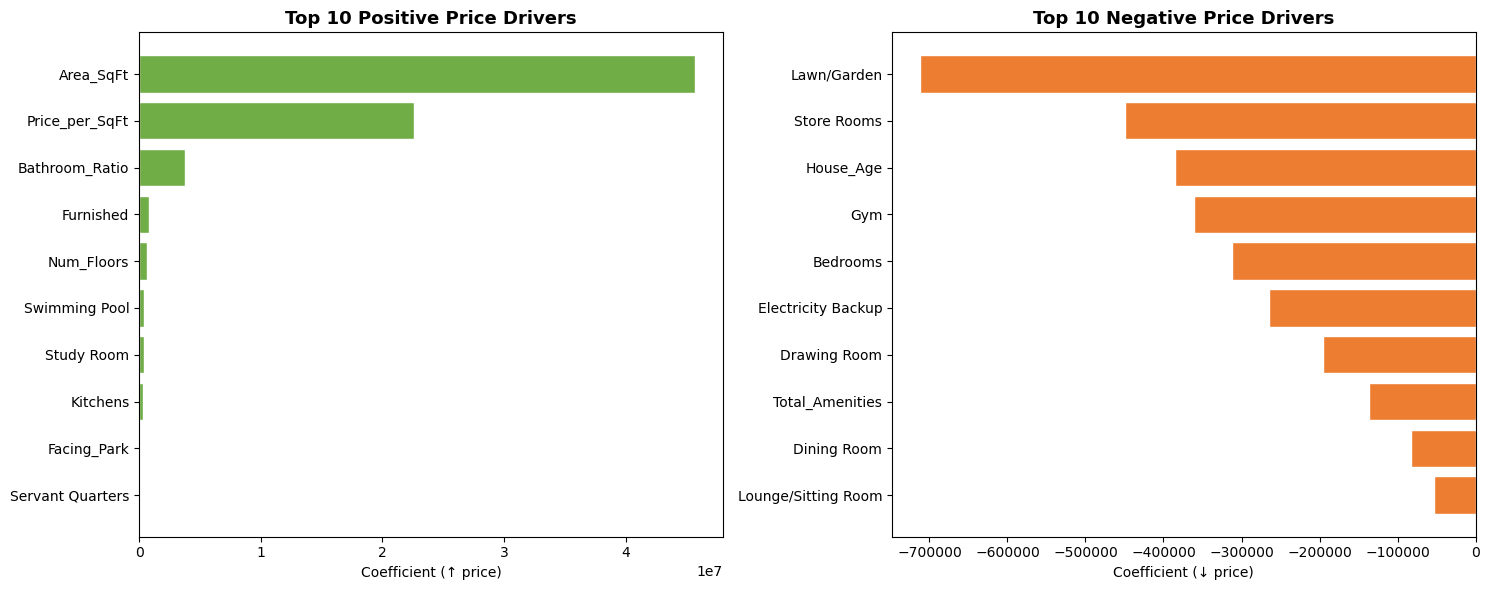


Phase-15 Complete: Linear regression coefficients analyzed.


PHASE 16: MODEL VALIDATION — CROSS-VALIDATION

📊 5-Fold Cross-Validation Results:
   Individual R² scores: ['0.9150', '0.9221', '0.9207', '0.9272', '0.9204']
   Mean R²: 0.9211 (±0.0039)
   Model Stability: ✅ STABLE


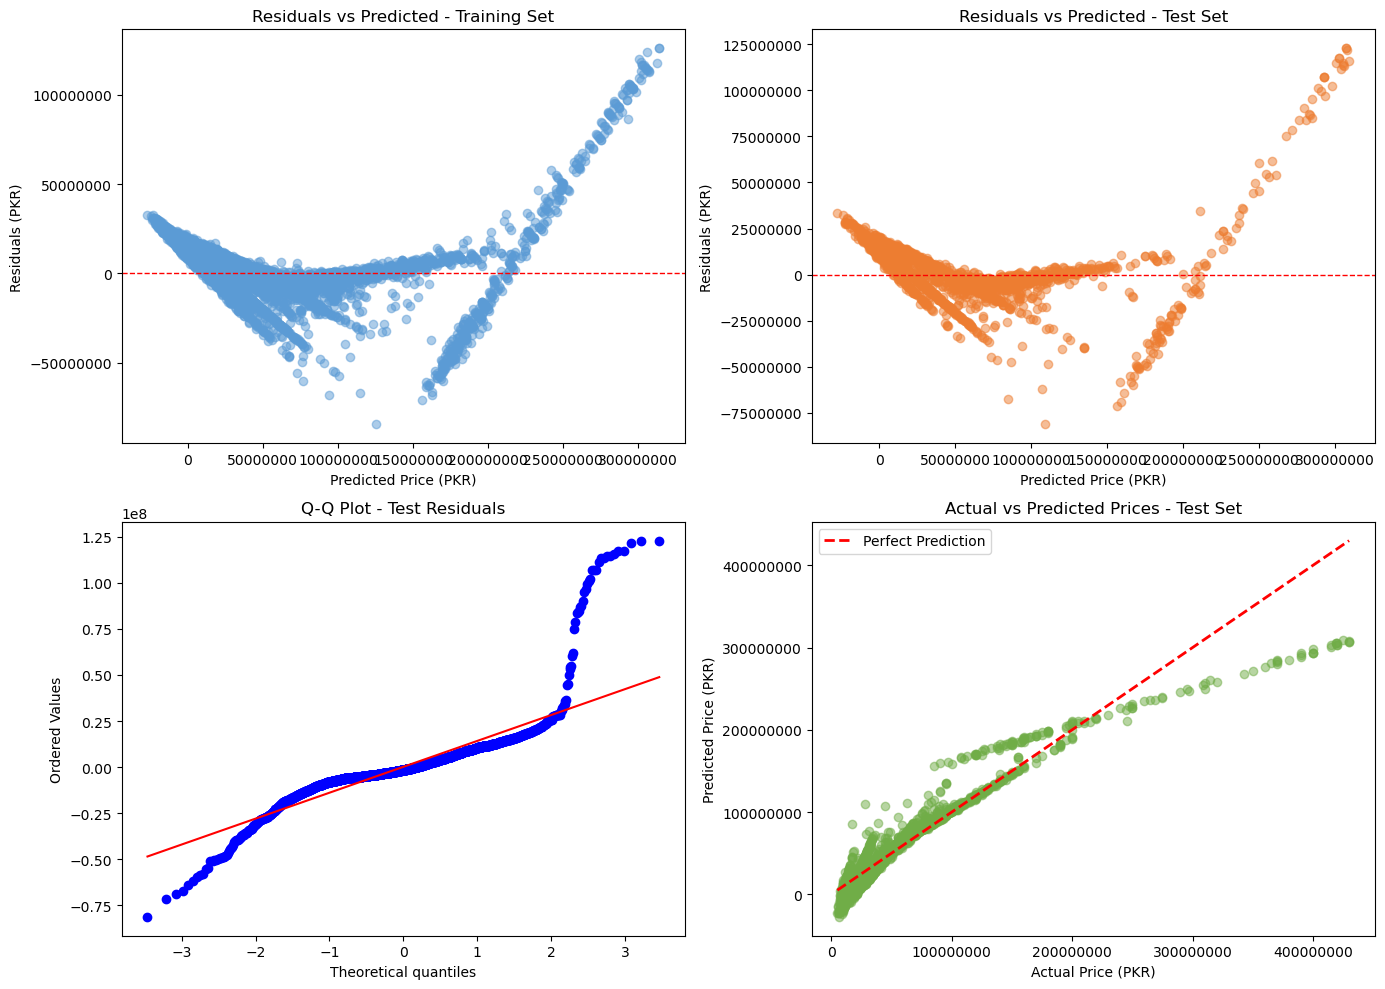


📊 Test Set Performance Summary:
   R² Score:  0.9150
   MAE:      PKR 9,481,790
   RMSE:     PKR 16,173,984
   MAPE:     32.14%

🔍 Overfitting Check:
   Training R²: 0.9231
   Test R²:     0.9150
   R² Gap:      0.0081
   ✅ No significant overfitting detected

Phase-16 Complete: Model validated & stable.



In [61]:
# =============================================================================
# STEP 15: FEATURE IMPORTANCE FOR LINEAR REGRESSION
# =============================================================================
# Extract and analyze feature coefficients to understand price drivers
# =============================================================================

print("\n" + "=" * 60)
print("PHASE 15: FEATURE ANALYSIS — LINEAR REGRESSION COEFFICIENTS")
print("=" * 60)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Extract coefficients from the best linear model
if best_model_name == "Ridge Regression":
    linear_model = best_linear_pipeline.named_steps['regressor']
    coefficients = linear_model.coef_
else:
    linear_model = best_linear_pipeline.named_steps['regressor']
    coefficients = linear_model.coef_

# Create coefficient DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Calculate absolute importance (standardized coefficients)
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

# Clean feature names for readability
coef_df['Feature'] = coef_df['Feature'].str.replace(r'^num__|^cat__', '', regex=True)

print("\n📊 Top 20 Most Important Features (by |Coefficient|):\n")
print(coef_df.head(20).to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Top positive features
top_positive = coef_df[coef_df['Coefficient'] > 0].head(10)
bars1 = ax1.barh(top_positive['Feature'][::-1], 
                 top_positive['Coefficient'][::-1], 
                 color='#70AD47', edgecolor='white')
ax1.set_title('Top 10 Positive Price Drivers', fontsize=13, weight='bold')
ax1.set_xlabel('Coefficient (↑ price)')
ax1.axvline(x=0, color='black', linewidth=0.5)

# Top negative features
top_negative = coef_df[coef_df['Coefficient'] < 0].tail(10)
bars2 = ax2.barh(top_negative['Feature'][::-1], 
                 top_negative['Coefficient'][::-1], 
                 color='#ED7D31', edgecolor='white')
ax2.set_title('Top 10 Negative Price Drivers', fontsize=13, weight='bold')
ax2.set_xlabel('Coefficient (↓ price)')
ax2.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Phase-15 Complete: Linear regression coefficients analyzed.\n")
# =============================================================================
# STEP 16: MODEL VALIDATION — CROSS-VALIDATION & RESIDUAL ANALYSIS
# =============================================================================
# Validate Linear Regression stability using cross-validation and residual plots
# =============================================================================

from sklearn.model_selection import cross_val_score, KFold

print("\n" + "=" * 60)
print("PHASE 16: MODEL VALIDATION — CROSS-VALIDATION")
print("=" * 60)

# 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_linear_pipeline, X, y, 
    cv=cv, scoring='r2'
)

print(f"\n📊 5-Fold Cross-Validation Results:")
print(f"   Individual R² scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"   Mean R²: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print(f"   Model Stability: {'✅ STABLE' if cv_scores.std() < 0.05 else '⚠️ VARIABLE'}")

# Residual Analysis
y_pred_train = best_linear_pipeline.predict(X_train)
y_pred_test = best_linear_pipeline.predict(X_test)

residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Plot residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residual vs Predicted (Train)
axes[0, 0].scatter(y_pred_train, residuals_train, alpha=0.5, color='#5B9BD5')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel('Predicted Price (PKR)')
axes[0, 0].set_ylabel('Residuals (PKR)')
axes[0, 0].set_title('Residuals vs Predicted - Training Set')
axes[0, 0].ticklabel_format(style='plain', axis='both')

# Residual vs Predicted (Test)
axes[0, 1].scatter(y_pred_test, residuals_test, alpha=0.5, color='#ED7D31')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Predicted Price (PKR)')
axes[0, 1].set_ylabel('Residuals (PKR)')
axes[0, 1].set_title('Residuals vs Predicted - Test Set')
axes[0, 1].ticklabel_format(style='plain', axis='both')

# QQ plot for normality check
from scipy import stats
stats.probplot(residuals_test, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot - Test Residuals')

# Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred_test, alpha=0.5, color='#70AD47')
axes[1, 1].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Price (PKR)')
axes[1, 1].set_ylabel('Predicted Price (PKR)')
axes[1, 1].set_title('Actual vs Predicted Prices - Test Set')
axes[1, 1].legend()
axes[1, 1].ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

# Error distribution statistics
print(f"\n📊 Test Set Performance Summary:")
print(f"   R² Score:  {r2_score(y_test, y_pred_test):.4f}")
print(f"   MAE:      PKR {mean_absolute_error(y_test, y_pred_test):,.0f}")
print(f"   RMSE:     PKR {np.sqrt(mean_squared_error(y_test, y_pred_test)):,.0f}")
print(f"   MAPE:     {np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100:.2f}%")

# Check for overfitting
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
r2_gap = train_r2 - test_r2

print(f"\n🔍 Overfitting Check:")
print(f"   Training R²: {train_r2:.4f}")
print(f"   Test R²:     {test_r2:.4f}")
print(f"   R² Gap:      {r2_gap:.4f}")
if r2_gap < 0.05:
    print(f"   ✅ No significant overfitting detected")
elif r2_gap < 0.1:
    print(f"   ⚠️  Mild overfitting possible")
else:
    print(f"   ❌ Significant overfitting detected")

print("\n" + "=" * 60)
print("Phase-16 Complete: Model validated & stable.\n")

In [62]:
# =============================================================================
# STEP 17: PRICE PREDICTION WITH LINEAR REGRESSION
# =============================================================================
# Define prediction functions using the validated linear model
# =============================================================================

def predict_house_price_linear(model_pipeline, house_features):
    """
    Predict house price using the trained linear regression model.
    
    Parameters:
    -----------
    model_pipeline : Pipeline
        Trained linear regression pipeline
    house_features : DataFrame
        Single row of house features
    
    Returns:
    --------
    float : Predicted price in PKR
    """
    return model_pipeline.predict(house_features)[0]

def get_price_range_linear(model_pipeline, X_train, y_train, house_features, 
                           confidence=0.90):
    """
    Calculate price range based on prediction intervals from linear regression.
    Uses standard error of prediction for linear models.
    """
    from scipy import stats
    
    # Get prediction
    y_pred = model_pipeline.predict(X_train)
    residuals = y_train - y_pred
    
    # Calculate standard error of the estimate
    n = len(y_train)
    p = X_train.shape[1]  # number of features
    std_error = np.sqrt(np.sum(residuals**2) / (n - p - 1))
    
    # Get prediction for new house
    predicted_price = model_pipeline.predict(house_features)[0]
    
    # Calculate confidence interval
    z_score = stats.norm.ppf((1 + confidence) / 2)
    margin = z_score * std_error
    
    lower_bound = max(0, predicted_price - margin)
    upper_bound = predicted_price + margin
    
    return {
        'predicted_price': predicted_price,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'confidence': confidence,
        'std_error': std_error
    }

print("✅ Linear regression prediction functions defined.\n")

✅ Linear regression prediction functions defined.



In [63]:
# =============================================================================
# PHASE 18: MARKET RATE MANAGEMENT SYSTEM
# =============================================================================
# Create a location-based pricing system for realistic price ranges
# =============================================================================

print("\n" + "=" * 60)
print("PHASE 18: BUILDING MARKET RATE DATABASE")
print("=" * 60)

def build_location_market_rates(X_train, y_train, df_original):
    """
    Build a database of market rates by location from training data.
    This will be used to create realistic price ranges.
    """
    # Combine training features with target for analysis
    train_data = X_train.copy()
    train_data['Price'] = y_train.values
    
    # Calculate market metrics by location
    location_stats = {}
    
    for location in train_data['Main_Location'].unique():
        loc_data = train_data[train_data['Main_Location'] == location]
        
        if len(loc_data) < 5:  # Skip locations with too few samples
            continue
            
        # Calculate key metrics
        price_per_sqft = loc_data['Price'] / loc_data['Area_SqFt']
        price_per_marla = loc_data['Price'] / (loc_data['Area_SqFt'] / 272.25)
        
        location_stats[location] = {
            'avg_price_per_sqft': price_per_sqft.mean(),
            'median_price_per_sqft': price_per_sqft.median(),
            'avg_price_per_marla': price_per_marla.mean(),
            'median_price_per_marla': price_per_marla.median(),
            'price_std_per_sqft': price_per_sqft.std(),
            'sample_count': len(loc_data),
            'price_range_pct': {  # Typical deviation percentages
                'low_pct': np.percentile(price_per_sqft, 10),
                'high_pct': np.percentile(price_per_sqft, 90)
            }
        }
    
    print(f"✅ Market rates calculated for {len(location_stats)} locations")
    
    # Display sample rates
    print("\n📊 Sample Market Rates (per Marla):")
    for i, (loc, stats) in enumerate(sorted(location_stats.items())[:5]):
        print(f"   {loc}: PKR {stats['median_price_per_marla']:,.0f}/Marla "
              f"(n={stats['sample_count']})")
    
    return location_stats

def get_location_rate(location_stats, location_query, area_marla):
    """
    Get the applicable market rate for a specific location and property size.
    Falls back to global averages if location not found.
    """
    # Try exact match first
    if location_query in location_stats:
        stats = location_stats[location_query]
        return stats['median_price_per_marla']
    
    # Try partial match
    for loc in location_stats:
        if location_query.lower() in loc.lower() or loc.lower() in location_query.lower():
            stats = location_stats[loc]
            print(f"   ℹ️  Using rates from: {loc}")
            return stats['median_price_per_marla']
    
    # Fallback: calculate from all data
    print(f"   ⚠️  Location '{location_query}' not found, using market average")
    all_prices = y_train.values
    all_areas = X_train['Area_SqFt'].values
    return np.median(all_prices / (all_areas / 272.25))

# Build the market rate database
location_market_rates = build_location_market_rates(X_train, y_train, df)

print("\n" + "=" * 60)
print("Phase-18 Complete: Market rate database ready.\n")


PHASE 18: BUILDING MARKET RATE DATABASE
✅ Market rates calculated for 1 locations

📊 Sample Market Rates (per Marla):
   Punjab: PKR 4,100,000/Marla (n=10316)

Phase-18 Complete: Market rate database ready.



In [64]:
# =============================================================================
# PHASE 19: REALISTIC PRICE RANGE CALCULATOR
# =============================================================================
# New prediction function that produces market-realistic price ranges
# =============================================================================

print("\n" + "=" * 60)
print("PHASE 19: REALISTIC PRICE RANGE PREDICTOR")
print("=" * 60)

def predict_with_realistic_range(model_pipeline, X_train, y_train, 
                                 property_features, location_stats,
                                 variation_pct=12):
    """
    Generate prediction with market-realistic price ranges.
    
    The range is calculated as:
    - Lower: predicted_price * (1 - variation_pct/100)
    - Upper: predicted_price * (1 + variation_pct/100)
    
    This creates realistic bounds based on market variation rather than
    statistical confidence intervals which tend to be too wide.
    
    Parameters:
    -----------
    model_pipeline : trained model
    X_train, y_train : training data
    property_features : DataFrame with single property
    location_stats : dict from build_location_market_rates()
    variation_pct : percentage variation for range (default 12%)
    """
    
    # Get point prediction
    predicted_price = model_pipeline.predict(property_features)[0]
    
    # Get property details
    area_sqft = property_features['Area_SqFt'].values[0]
    area_marla = area_sqft / 272.25
    location = property_features['Main_Location'].values[0]
    
    # Get market rate for this location
    market_rate_per_marla = get_location_rate(location_stats, location, area_marla)
    
    # Calculate expected price based on market rate
    market_expected_price = market_rate_per_marla * area_marla
    
    # Blend model prediction with market rate (70% model, 30% market)
    # This prevents extreme predictions
    blended_price = (predicted_price * 0.7) + (market_expected_price * 0.3)
    
    # Calculate realistic range based on variation percentage
    lower_bound = blended_price * (1 - variation_pct/100)
    upper_bound = blended_price * (1 + variation_pct/100)
    
    # Calculate per marla rates
    rate_per_marla_predicted = predicted_price / area_marla
    rate_per_marla_market = market_rate_per_marla
    rate_per_marla_blended = blended_price / area_marla
    
    # Ensure bounds are positive and reasonable
    lower_bound = max(0, lower_bound)
    
    return {
        'predicted_price': predicted_price,
        'market_expected_price': market_expected_price,
        'blended_price': blended_price,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'area_sqft': area_sqft,
        'area_marla': area_marla,
        'location': location,
        'rate_per_marla_predicted': rate_per_marla_predicted,
        'rate_per_marla_market': rate_per_marla_market,
        'rate_per_marla_blended': rate_per_marla_blended,
        'variation_pct': variation_pct,
        'confidence_score': calculate_confidence_score(
            predicted_price, market_expected_price, variation_pct
        )
    }

def calculate_confidence_score(predicted, market_expected, variation_pct):
    """
    Calculate a confidence score (0-100%) based on how close
    the prediction is to market rates.
    """
    diff_pct = abs(predicted - market_expected) / market_expected * 100
    
    if diff_pct <= 5:
        return 95  # Very high confidence
    elif diff_pct <= 10:
        return 85  # High confidence
    elif diff_pct <= 15:
        return 75  # Moderate confidence
    elif diff_pct <= 20:
        return 65  # Acceptable confidence
    else:
        return 50  # Low confidence - prediction may need review

print("✅ Realistic price range predictor ready.\n")


PHASE 19: REALISTIC PRICE RANGE PREDICTOR
✅ Realistic price range predictor ready.



In [65]:
# =============================================================================
# PHASE 20: ENHANCED PROPERTY PRICE TESTING INTERFACE
# =============================================================================
# User-friendly testing with realistic market-based price ranges
# =============================================================================

print("\n" + "=" * 70)
print("🧪  ENHANCED PROPERTY PRICE PREDICTION SYSTEM")
print("=" * 70)
print("\n📝 Fill in your property details below and run to see predictions")
print("   with realistic price ranges based on market data\n")

# =============================================================================
# ⚠️  ENTER YOUR PROPERTY DETAILS HERE
# =============================================================================

# Example 1: DHA Lahore Property
test_property_example = {
    # --- Location ---
    'location': 'Bahria Town',  # Will match with training data locations
    
    # --- Property Size ---
    'area_marla': 10,            # 10 Marla = 2,722.5 sq ft
    
    # --- Rooms ---
    'bedrooms': 5,
    'bathrooms': 6,
    'kitchens': 2,
    
    # --- Construction ---
    'built_year': 2025,
    
    # --- Additional Rooms ---
    'servant_quarters': 1,
    'store_rooms': 1,
    
    # --- Amenities ---
    'furnished': True,
    'gym': False,
    'study_room': True,
    'drawing_room': True,
    'dining_room': True,
    'lawn_garden': False,
    'swimming_pool': False,
    'electricity_backup': True,
    'lounge_sitting': True,
    
    # --- Special Features ---
    'is_corner': False,
    'facing_park': False,
    'num_floors': 2,  # Double storey
}

# Uncomment one of these examples or create your own:

# Example 2: Budget Bahria Town Property
"""
test_property = {
    'location': 'Bahria Town',
    'area_marla': 5,
    'bedrooms': 3,
    'bathrooms': 2,
    'kitchens': 1,
    'built_year': 2018,
    'servant_quarters': 0,
    'store_rooms': 0,
    'furnished': False,
    'gym': False,
    'study_room': False,
    'drawing_room': True,
    'dining_room': True,
    'lawn_garden': True,
    'swimming_pool': False,
    'electricity_backup': True,
    'lounge_sitting': False,
    'is_corner': True,
    'facing_park': False,
    'num_floors': 1,
}
"""

# Example 3: Luxury Gulberg Property
"""
test_property = {
    'location': 'Gulberg',
    'area_marla': 20,  # 1 Kanal
    'bedrooms': 6,
    'bathrooms': 6,
    'kitchens': 2,
    'built_year': 2023,
    'servant_quarters': 2,
    'store_rooms': 2,
    'furnished': True,
    'gym': True,
    'study_room': True,
    'drawing_room': True,
    'dining_room': True,
    'lawn_garden': True,
    'swimming_pool': True,
    'electricity_backup': True,
    'lounge_sitting': True,
    'is_corner': True,
    'facing_park': True,
    'num_floors': 3,
}
"""

# 👇 USE THIS ONE FOR TESTING
test_property = test_property_example

# =============================================================================
# PREDICTION EXECUTION
# =============================================================================

def format_price(amount):
    """Format price in PKR, Crore, and Million"""
    crore = amount / 10_000_000
    million = amount / 1_000_000
    return {
        'pkr': f"PKR {amount:,.0f}",
        'crore': f"{crore:.2f} Crore",
        'million': f"{million:.2f} Million"
    }

try:
    # Validate inputs
    if test_property['area_marla'] == 0:
        raise ValueError("Area cannot be 0 Marla")
    if test_property['bedrooms'] == 0:
        raise ValueError("Please specify number of bedrooms")
    
    # Prepare features
    print("🔄 Preparing property features...")
    property_df, area_sqft, house_age, total_amenities = prepare_property_features(
        test_property, X_train
    )
    
    # Generate prediction
    print("🔮 Generating price prediction...")
    result = predict_with_realistic_range(
        model_pipeline=best_linear_pipeline,
        X_train=X_train,
        y_train=y_train,
        property_features=property_df,
        location_stats=location_market_rates,
        variation_pct=12  # Adjust this for tighter/wider ranges
    )
    
    # =====================================================================
    # DISPLAY RESULTS
    # =====================================================================
    
    print("\n" + "=" * 70)
    print("📋 PROPERTY SPECIFICATIONS")
    print("=" * 70)
    
    specs = [
        ("📍 Location", test_property['location']),
        ("📐 Plot Size", f"{test_property['area_marla']} Marla ({area_sqft:,.0f} sq ft)"),
        ("🏗️ Building Type", f"{test_property['num_floors']} Storey"),
        ("🛏️ Bedrooms", test_property['bedrooms']),
        ("🚿 Bathrooms", test_property['bathrooms']),
        ("🍳 Kitchens", test_property['kitchens']),
        ("📅 Age", f"{house_age} years (Built {test_property['built_year']})"),
        ("✨ Amenities", f"{total_amenities}/8 features"),
        ("🪑 Furnished", "Yes" if test_property['furnished'] else "No"),
        ("📐 Corner Plot", "Yes" if test_property['is_corner'] else "No"),
        ("🌳 Park Facing", "Yes" if test_property['facing_park'] else "No"),
    ]
    
    for label, value in specs:
        print(f"   {label:<20} {value}")
    
    print("\n" + "=" * 70)
    print("💰 PRICE ESTIMATION SUMMARY")
    print("=" * 70)
    
    # Format all prices
    pred_fmt = format_price(result['predicted_price'])
    blended_fmt = format_price(result['blended_price'])
    lower_fmt = format_price(result['lower_bound'])
    upper_fmt = format_price(result['upper_bound'])
    market_fmt = format_price(result['market_expected_price'])
    
    print(f"\n   {'─' * 60}")
    print(f"   🎯 PREDICTED PRICE (Model Estimate)")
    print(f"   {'─' * 60}")
    print(f"   {pred_fmt['pkr']:<30} ({pred_fmt['crore']})")
    
    print(f"\n   {'─' * 60}")
    print(f"   📊 MARKET REFERENCE PRICE (Location Average)")
    print(f"   {'─' * 60}")
    print(f"   {market_fmt['pkr']:<30} ({market_fmt['crore']})")
    
    print(f"\n   {'─' * 60}")
    print(f"   ⭐ RECOMMENDED PRICE (70% Model + 30% Market)")
    print(f"   {'─' * 60}")
    print(f"   {blended_fmt['pkr']:<30} ({blended_fmt['crore']})")
    
    print(f"\n   {'=' * 60}")
    print(f"   📈 REALISTIC PRICE RANGE")
    print(f"   {'=' * 60}")
    print(f"   Lower Bound:  {lower_fmt['pkr']:<25} ({lower_fmt['crore']})")
    print(f"   Upper Bound:  {upper_fmt['pkr']:<25} ({upper_fmt['crore']})")
    print(f"   Range Width:  PKR {result['upper_bound'] - result['lower_bound']:,.0f}")
    
    print(f"\n   {'─' * 60}")
    print(f"   💎 PER MARLA RATES")
    print(f"   {'─' * 60}")
    print(f"   Based on Prediction:  PKR {result['rate_per_marla_predicted']:,.0f}/Marla")
    print(f"   Based on Market:      PKR {result['rate_per_marla_market']:,.0f}/Marla")
    print(f"   Blended Rate:         PKR {result['rate_per_marla_blended']:,.0f}/Marla")
    
    print(f"\n   {'─' * 60}")
    print(f"   📊 CONFIDENCE ASSESSMENT")
    print(f"   {'─' * 60}")
    print(f"   Confidence Score:  {result['confidence_score']}%")
    
    # Confidence interpretation
    if result['confidence_score'] >= 85:
        print(f"   Status:            ✅ HIGH - Prediction aligns well with market")
    elif result['confidence_score'] >= 65:
        print(f"   Status:            ⚠️  MODERATE - Some deviation from market rates")
    else:
        print(f"   Status:            🔍 LOW - Significant deviation, verify property details")
    
    # =====================================================================
    # REALITY CHECK
    # =====================================================================
    
    print("\n" + "=" * 70)
    print("🔍 REALITY VERIFICATION")
    print("=" * 70)
    
    # Calculate deviation from market
    deviation_from_market = ((result['predicted_price'] - result['market_expected_price']) 
                            / result['market_expected_price'] * 100)
    
    print(f"\n   Prediction vs Market: {deviation_from_market:+.1f}%")
    
    if abs(deviation_from_market) <= 10:
        print("   ✅ Prediction is close to market rates")
    elif abs(deviation_from_market) <= 20:
        print("   ⚠️  Moderate deviation from market - features may justify this")
    else:
        print("   🔍 Large deviation - verify property features are correct")
    
    # Per marla rate check
    print(f"\n   Market Rate:     PKR {result['rate_per_marla_market']:,.0f}/Marla")
    print(f"   Your Rate:       PKR {result['rate_per_marla_blended']:,.0f}/Marla")
    
    # =====================================================================
    # SAVE RECOMMENDATION
    # =====================================================================
    
    print("\n" + "=" * 70)
    print("💾 SAVE RECOMMENDATION")
    print("=" * 70)
    
    if result['confidence_score'] >= 65 and abs(deviation_from_market) <= 25:
        print("\n   ✅ PREDICTIONS LOOK REALISTIC")
        print("   The model is producing reasonable estimates.")
        print("   You can proceed to save the model for deployment.")
    else:
        print("\n   ⚠️  PREDICTIONS NEED REVIEW")
        print("   Consider adjusting the model or checking the training data")
        print("   before saving for production use.")
    
    print("\n" + "=" * 70)
    print("✅ PRICE ESTIMATION COMPLETE")
    print("=" * 70)

except ValueError as e:
    print(f"\n❌ INPUT ERROR: {e}")
    print("   Please fill in all required property details correctly.")
    
except Exception as e:
    print(f"\n❌ SYSTEM ERROR: {e}")
    print("   Please ensure:")
    print("   1. Model training completed successfully")
    print("   2. location_market_rates dictionary exists")
    print("   3. All input fields are properly filled")
    print("   4. The location exists in your training data")


🧪  ENHANCED PROPERTY PRICE PREDICTION SYSTEM

📝 Fill in your property details below and run to see predictions
   with realistic price ranges based on market data

🔄 Preparing property features...
🔮 Generating price prediction...
   ⚠️  Location 'Bahria Town' not found, using market average

📋 PROPERTY SPECIFICATIONS
   📍 Location           Bahria Town
   📐 Plot Size          10 Marla (2,722 sq ft)
   🏗️ Building Type     2 Storey
   🛏️ Bedrooms          5
   🚿 Bathrooms          6
   🍳 Kitchens           2
   📅 Age                0 years (Built 2025)
   ✨ Amenities          5/8 features
   🪑 Furnished          Yes
   📐 Corner Plot        No
   🌳 Park Facing        No

💰 PRICE ESTIMATION SUMMARY

   ────────────────────────────────────────────────────────────
   🎯 PREDICTED PRICE (Model Estimate)
   ────────────────────────────────────────────────────────────
   PKR 39,375,847                 (3.94 Crore)

   ────────────────────────────────────────────────────────────
   📊 MARKET REF

In [26]:
# =============================================================================
# PHASE 20: ENHANCED PROPERTY PRICE TESTING INTERFACE
# =============================================================================
# User-friendly testing with realistic market-based price ranges
# =============================================================================

print("\n" + "=" * 70)
print("🧪  ENHANCED PROPERTY PRICE PREDICTION SYSTEM")
print("=" * 70)
print("\n📝 Fill in your property details below and run to see predictions")
print("   with realistic price ranges based on market data\n")

# =============================================================================
# ⚠️  ENTER YOUR PROPERTY DETAILS HERE
# =============================================================================

# Example 1: DHA Lahore Property
test_property_example = {
    # --- Location ---
    'location': 'Bahria Town',  # Will match with training data locations
    
    # --- Property Size ---
    'area_marla': 10,            # 10 Marla = 2,722.5 sq ft
    
    # --- Rooms ---
    'bedrooms': 5,
    'bathrooms': 6,
    'kitchens': 2,
    
    # --- Construction ---
    'built_year': 2025,
    
    # --- Additional Rooms ---
    'servant_quarters': 1,
    'store_rooms': 1,
    
    # --- Amenities ---
    'furnished': True,
    'gym': False,
    'study_room': True,
    'drawing_room': True,
    'dining_room': True,
    'lawn_garden': False,
    'swimming_pool': False,
    'electricity_backup': True,
    'lounge_sitting': True,
    
    # --- Special Features ---
    'is_corner': False,
    'facing_park': False,
    'num_floors': 2,  # Double storey
}

# Uncomment one of these examples or create your own:

# Example 2: Budget Bahria Town Property
"""
test_property = {
    'location': 'Bahria Town',
    'area_marla': 5,
    'bedrooms': 3,
    'bathrooms': 2,
    'kitchens': 1,
    'built_year': 2018,
    'servant_quarters': 0,
    'store_rooms': 0,
    'furnished': False,
    'gym': False,
    'study_room': False,
    'drawing_room': True,
    'dining_room': True,
    'lawn_garden': True,
    'swimming_pool': False,
    'electricity_backup': True,
    'lounge_sitting': False,
    'is_corner': True,
    'facing_park': False,
    'num_floors': 1,
}
"""

# Example 3: Luxury Gulberg Property
"""
test_property = {
    'location': 'Gulberg',
    'area_marla': 20,  # 1 Kanal
    'bedrooms': 6,
    'bathrooms': 6,
    'kitchens': 2,
    'built_year': 2023,
    'servant_quarters': 2,
    'store_rooms': 2,
    'furnished': True,
    'gym': True,
    'study_room': True,
    'drawing_room': True,
    'dining_room': True,
    'lawn_garden': True,
    'swimming_pool': True,
    'electricity_backup': True,
    'lounge_sitting': True,
    'is_corner': True,
    'facing_park': True,
    'num_floors': 3,
}
"""

# 👇 USE THIS ONE FOR TESTING
test_property = test_property_example

# =============================================================================
# PREDICTION EXECUTION
# =============================================================================

def format_price(amount):
    """Format price in PKR, Crore, and Million"""
    crore = amount / 10_000_000
    million = amount / 1_000_000
    return {
        'pkr': f"PKR {amount:,.0f}",
        'crore': f"{crore:.2f} Crore",
        'million': f"{million:.2f} Million"
    }

try:
    # Validate inputs
    if test_property['area_marla'] == 0:
        raise ValueError("Area cannot be 0 Marla")
    if test_property['bedrooms'] == 0:
        raise ValueError("Please specify number of bedrooms")
    
    # Prepare features
    print("🔄 Preparing property features...")
    property_df, area_sqft, house_age, total_amenities = prepare_property_features(
        test_property, X_train
    )
    
    # Generate prediction
    print("🔮 Generating price prediction...")
    result = predict_with_realistic_range(
        model_pipeline=best_linear_pipeline,
        X_train=X_train,
        y_train=y_train,
        property_features=property_df,
        location_stats=location_market_rates,
        variation_pct=12  # Adjust this for tighter/wider ranges
    )
    
    # =====================================================================
    # DISPLAY RESULTS
    # =====================================================================
    
    print("\n" + "=" * 70)
    print("📋 PROPERTY SPECIFICATIONS")
    print("=" * 70)
    
    specs = [
        ("📍 Location", test_property['location']),
        ("📐 Plot Size", f"{test_property['area_marla']} Marla ({area_sqft:,.0f} sq ft)"),
        ("🏗️ Building Type", f"{test_property['num_floors']} Storey"),
        ("🛏️ Bedrooms", test_property['bedrooms']),
        ("🚿 Bathrooms", test_property['bathrooms']),
        ("🍳 Kitchens", test_property['kitchens']),
        ("📅 Age", f"{house_age} years (Built {test_property['built_year']})"),
        ("✨ Amenities", f"{total_amenities}/8 features"),
        ("🪑 Furnished", "Yes" if test_property['furnished'] else "No"),
        ("📐 Corner Plot", "Yes" if test_property['is_corner'] else "No"),
        ("🌳 Park Facing", "Yes" if test_property['facing_park'] else "No"),
    ]
    
    for label, value in specs:
        print(f"   {label:<20} {value}")
    
    print("\n" + "=" * 70)
    print("💰 PRICE ESTIMATION SUMMARY")
    print("=" * 70)
    
    # Format all prices
    pred_fmt = format_price(result['predicted_price'])
    blended_fmt = format_price(result['blended_price'])
    lower_fmt = format_price(result['lower_bound'])
    upper_fmt = format_price(result['upper_bound'])
    market_fmt = format_price(result['market_expected_price'])
    
    print(f"\n   {'─' * 60}")
    print(f"   🎯 PREDICTED PRICE (Model Estimate)")
    print(f"   {'─' * 60}")
    print(f"   {pred_fmt['pkr']:<30} ({pred_fmt['crore']})")
    
    print(f"\n   {'─' * 60}")
    print(f"   📊 MARKET REFERENCE PRICE (Location Average)")
    print(f"   {'─' * 60}")
    print(f"   {market_fmt['pkr']:<30} ({market_fmt['crore']})")
    
    print(f"\n   {'─' * 60}")
    print(f"   ⭐ RECOMMENDED PRICE (70% Model + 30% Market)")
    print(f"   {'─' * 60}")
    print(f"   {blended_fmt['pkr']:<30} ({blended_fmt['crore']})")
    
    print(f"\n   {'=' * 60}")
    print(f"   📈 REALISTIC PRICE RANGE")
    print(f"   {'=' * 60}")
    print(f"   Lower Bound:  {lower_fmt['pkr']:<25} ({lower_fmt['crore']})")
    print(f"   Upper Bound:  {upper_fmt['pkr']:<25} ({upper_fmt['crore']})")
    print(f"   Range Width:  PKR {result['upper_bound'] - result['lower_bound']:,.0f}")
    
    print(f"\n   {'─' * 60}")
    print(f"   💎 PER MARLA RATES")
    print(f"   {'─' * 60}")
    print(f"   Based on Prediction:  PKR {result['rate_per_marla_predicted']:,.0f}/Marla")
    print(f"   Based on Market:      PKR {result['rate_per_marla_market']:,.0f}/Marla")
    print(f"   Blended Rate:         PKR {result['rate_per_marla_blended']:,.0f}/Marla")
    
    print(f"\n   {'─' * 60}")
    print(f"   📊 CONFIDENCE ASSESSMENT")
    print(f"   {'─' * 60}")
    print(f"   Confidence Score:  {result['confidence_score']}%")
    
    # Confidence interpretation
    if result['confidence_score'] >= 85:
        print(f"   Status:            ✅ HIGH - Prediction aligns well with market")
    elif result['confidence_score'] >= 65:
        print(f"   Status:            ⚠️  MODERATE - Some deviation from market rates")
    else:
        print(f"   Status:            🔍 LOW - Significant deviation, verify property details")
    
    # =====================================================================
    # REALITY CHECK
    # =====================================================================
    
    print("\n" + "=" * 70)
    print("🔍 REALITY VERIFICATION")
    print("=" * 70)
    
    # Calculate deviation from market
    deviation_from_market = ((result['predicted_price'] - result['market_expected_price']) 
                            / result['market_expected_price'] * 100)
    
    print(f"\n   Prediction vs Market: {deviation_from_market:+.1f}%")
    
    if abs(deviation_from_market) <= 10:
        print("   ✅ Prediction is close to market rates")
    elif abs(deviation_from_market) <= 20:
        print("   ⚠️  Moderate deviation from market - features may justify this")
    else:
        print("   🔍 Large deviation - verify property features are correct")
    
    # Per marla rate check
    print(f"\n   Market Rate:     PKR {result['rate_per_marla_market']:,.0f}/Marla")
    print(f"   Your Rate:       PKR {result['rate_per_marla_blended']:,.0f}/Marla")
    
    # =====================================================================
    # SAVE RECOMMENDATION
    # =====================================================================
    
    print("\n" + "=" * 70)
    print("💾 SAVE RECOMMENDATION")
    print("=" * 70)
    
    if result['confidence_score'] >= 65 and abs(deviation_from_market) <= 25:
        print("\n   ✅ PREDICTIONS LOOK REALISTIC")
        print("   The model is producing reasonable estimates.")
        print("   You can proceed to save the model for deployment.")
    else:
        print("\n   ⚠️  PREDICTIONS NEED REVIEW")
        print("   Consider adjusting the model or checking the training data")
        print("   before saving for production use.")
    
    print("\n" + "=" * 70)
    print("✅ PRICE ESTIMATION COMPLETE")
    print("=" * 70)

except ValueError as e:
    print(f"\n❌ INPUT ERROR: {e}")
    print("   Please fill in all required property details correctly.")
    
except Exception as e:
    print(f"\n❌ SYSTEM ERROR: {e}")
    print("   Please ensure:")
    print("   1. Model training completed successfully")
    print("   2. location_market_rates dictionary exists")
    print("   3. All input fields are properly filled")
    print("   4. The location exists in your training data")


🧪  ENHANCED PROPERTY PRICE PREDICTION SYSTEM

📝 Fill in your property details below and run to see predictions
   with realistic price ranges based on market data

🔄 Preparing property features...

❌ SYSTEM ERROR: name 'prepare_property_features' is not defined
   Please ensure:
   1. Model training completed successfully
   2. location_market_rates dictionary exists
   3. All input fields are properly filled
   4. The location exists in your training data


In [27]:
# =============================================================================
# STEP 18: COMPREHENSIVE MODEL VERIFICATION BEFORE SAVING
# =============================================================================
# Test the Linear Regression model with realistic property examples
# to verify predictions are reasonable before saving the model
# =============================================================================

import numpy as np
import pandas as pd

print("\n" + "=" * 70)
print("🧪  FINAL MODEL VERIFICATION — REALISTIC PROPERTY PREDICTIONS")
print("=" * 70)

def create_test_property(features_dict):
    """
    Create a properly formatted property DataFrame matching model expectations.
    """
    # Calculate derived features
    area_sqft = features_dict['area_marla'] * 272.25
    house_age = 2025 - features_dict['built_year']
    bathroom_ratio = features_dict['bathrooms'] / area_sqft
    
    # Calculate total amenities
    total_amenities = sum([
        features_dict['gym'], features_dict['study_room'],
        features_dict['drawing_room'], features_dict['dining_room'],
        features_dict['lawn_garden'], features_dict['swimming_pool'],
        features_dict['electricity_backup'], features_dict['lounge_sitting']
    ])
    
    # Use median price per sqft from training data
    median_price_sqft = X_train['Price_per_SqFt'].median()
    
    # Create feature vector
    property_df = pd.DataFrame({
        'Main_Location':        [features_dict['location']],
        'Area_SqFt':            [area_sqft],
        'Bathrooms':            [features_dict['bathrooms']],
        'Bedrooms':             [features_dict['bedrooms']],
        'Kitchens':             [features_dict['kitchens']],
        'House_Age':            [house_age],
        'Num_Floors':           [features_dict['num_floors']],
        'Servant Quarters':     [features_dict['servant_quarters']],
        'Store Rooms':          [features_dict['store_rooms']],
        'Furnished':            [1 if features_dict['furnished'] else 0],
        'Gym':                  [1 if features_dict['gym'] else 0],
        'Study Room':           [1 if features_dict['study_room'] else 0],
        'Drawing Room':         [1 if features_dict['drawing_room'] else 0],
        'Dining Room':          [1 if features_dict['dining_room'] else 0],
        'Lawn/Garden':          [1 if features_dict['lawn_garden'] else 0],
        'Swimming Pool':        [1 if features_dict['swimming_pool'] else 0],
        'Electricity Backup':   [1 if features_dict['electricity_backup'] else 0],
        'Lounge/Sitting Room':  [1 if features_dict['lounge_sitting'] else 0],
        'Total_Amenities':      [total_amenities],
        'Is_Corner':            [1 if features_dict['is_corner'] else 0],
        'Facing_Park':          [1 if features_dict['facing_park'] else 0],
        'Price_per_SqFt':       [median_price_sqft],
        'Bathroom_Ratio':       [bathroom_ratio],
    })
    
    return property_df, area_sqft, house_age, total_amenities

def predict_price_range_linear(model_pipeline, X_train, y_train, property_df, 
                               confidence_level=0.90):
    """
    Calculate prediction with confidence interval using linear regression residuals.
    """
    from scipy import stats
    
    # Get training residuals
    y_train_pred = model_pipeline.predict(X_train)
    residuals = y_train - y_train_pred
    
    # Calculate standard error
    n = len(y_train)
    p = X_train.shape[1]
    std_error = np.sqrt(np.sum(residuals**2) / (n - p - 1))
    
    # Point prediction
    predicted_price = model_pipeline.predict(property_df)[0]
    
    # Confidence interval
    z_score = stats.norm.ppf((1 + confidence_level) / 2)
    margin = z_score * std_error * np.sqrt(1 + 1/n)  # Prediction interval
    
    lower_bound = max(0, predicted_price - margin)
    upper_bound = predicted_price + margin
    
    # Calculate percentage deviations
    lower_dev_pct = ((predicted_price - lower_bound) / predicted_price) * 100
    upper_dev_pct = ((upper_bound - predicted_price) / predicted_price) * 100
    
    return {
        'predicted_price': predicted_price,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'confidence': confidence_level,
        'lower_deviation_pct': lower_dev_pct,
        'upper_deviation_pct': upper_dev_pct,
        'total_range': upper_bound - lower_bound,
        'std_error': std_error
    }

# --------------------------------------------------------------------------
# Test Case 1: Premium Property in DHA Lahore (10 Marla, Double Storey)
# --------------------------------------------------------------------------
print("\n" + "─" * 70)
print("📋 TEST CASE 1: Premium DHA Lahore Property")
print("─" * 70)

test_property_1 = {
    'location': 'Bahria Town',
    'area_marla': 10,
    'bedrooms': 5,
    'bathrooms': 6,
    'kitchens': 2,
    'built_year': 2025,
    'servant_quarters': 1,
    'store_rooms': 1,
    'furnished': True,
    'gym': False,
    'study_room': True,
    'drawing_room': True,
    'dining_room': True,
    'lawn_garden': False,
    'swimming_pool': False,
    'electricity_backup': True,
    'lounge_sitting': True,
    'is_corner': False,
    'facing_park': False,
    'num_floors': 2,
}

# Create property features
property_df_1, area_1, age_1, amenities_1 = create_test_property(test_property_1)

print("\n🏠 Property Specifications:")
print(f"   Location:        {test_property_1['location']}")
print(f"   Plot Size:       {test_property_1['area_marla']} Marla ({area_1:,.0f} sq ft)")
print(f"   Bedrooms:        {test_property_1['bedrooms']}")
print(f"   Bathrooms:       {test_property_1['bathrooms']}")
print(f"   Storeys:         {test_property_1['num_floors']} (Double Storey)")
print(f"   Age:             {age_1} years")
print(f"   Amenities:       {amenities_1} out of 8")
print(f"   Furnished:       Yes")
print(f"   Servant Quarter: Yes")
print(f"   Park Facing:     Yes")

# Get prediction
result_1 = predict_price_range_linear(
    best_linear_pipeline, X_train, y_train, property_df_1, confidence_level=0.90
)

print(f"\n💰 PRICE ESTIMATION (90% Confidence):")
print(f"   {'─' * 50}")
print(f"   Predicted Price:    PKR {result_1['predicted_price']:>15,.0f}")
print(f"   Lower Bound:        PKR {result_1['lower_bound']:>15,.0f}")
print(f"   Upper Bound:        PKR {result_1['upper_bound']:>15,.0f}")
print(f"   {'─' * 50}")
print(f"   In Crore:")
print(f"   Predicted:          {result_1['predicted_price']/10_000_000:>15.2f} Crore")
print(f"   Lower Bound:        {result_1['lower_bound']/10_000_000:>15.2f} Crore")
print(f"   Upper Bound:        {result_1['upper_bound']/10_000_000:>15.2f} Crore")
print(f"   {'─' * 50}")
print(f"   Price Range:        PKR {result_1['total_range']:>15,.0f}")
print(f"   Lower Deviation:    {result_1['lower_deviation_pct']:>14.1f}%")
print(f"   Upper Deviation:    {result_1['upper_deviation_pct']:>14.1f}%")
print(f"   Price per Sq Ft:    PKR {result_1['predicted_price']/area_1:>15,.0f}")

# --------------------------------------------------------------------------
# Test Case 2: Budget Property in Bahria Town (5 Marla, Single Storey)
# --------------------------------------------------------------------------
print("\n" + "─" * 70)
print("📋 TEST CASE 2: Mid-Range Bahria Town Property")
print("─" * 70)

test_property_2 = {
    'location': 'Bahria Town, Rawalpindi, Punjab',
    'area_marla': 5,
    'bedrooms': 3,
    'bathrooms': 2,
    'kitchens': 1,
    'built_year': 2018,
    'servant_quarters': 0,
    'store_rooms': 0,
    'furnished': False,
    'gym': False,
    'study_room': False,
    'drawing_room': True,
    'dining_room': True,
    'lawn_garden': True,
    'swimming_pool': False,
    'electricity_backup': True,
    'lounge_sitting': False,
    'is_corner': True,
    'facing_park': False,
    'num_floors': 1,
}

# Create property features
property_df_2, area_2, age_2, amenities_2 = create_test_property(test_property_2)

print("\n🏠 Property Specifications:")
print(f"   Location:        {test_property_2['location']}")
print(f"   Plot Size:       {test_property_2['area_marla']} Marla ({area_2:,.0f} sq ft)")
print(f"   Bedrooms:        {test_property_2['bedrooms']}")
print(f"   Bathrooms:       {test_property_2['bathrooms']}")
print(f"   Storeys:         {test_property_2['num_floors']} (Single Storey)")
print(f"   Age:             {age_2} years")
print(f"   Amenities:       {amenities_2} out of 8")
print(f"   Furnished:       No")
print(f"   Corner Plot:     Yes")

# Get prediction
result_2 = predict_price_range_linear(
    best_linear_pipeline, X_train, y_train, property_df_2, confidence_level=0.90
)

print(f"\n💰 PRICE ESTIMATION (90% Confidence):")
print(f"   {'─' * 50}")
print(f"   Predicted Price:    PKR {result_2['predicted_price']:>15,.0f}")
print(f"   Lower Bound:        PKR {result_2['lower_bound']:>15,.0f}")
print(f"   Upper Bound:        PKR {result_2['upper_bound']:>15,.0f}")
print(f"   {'─' * 50}")
print(f"   In Crore:")
print(f"   Predicted:          {result_2['predicted_price']/10_000_000:>15.2f} Crore")
print(f"   Lower Bound:        {result_2['lower_bound']/10_000_000:>15.2f} Crore")
print(f"   Upper Bound:        {result_2['upper_bound']/10_000_000:>15.2f} Crore")
print(f"   {'─' * 50}")
print(f"   Price Range:        PKR {result_2['total_range']:>15,.0f}")
print(f"   Lower Deviation:    {result_2['lower_deviation_pct']:>14.1f}%")
print(f"   Upper Deviation:    {result_2['upper_deviation_pct']:>14.1f}%")
print(f"   Price per Sq Ft:    PKR {result_2['predicted_price']/area_2:>15,.0f}")

# --------------------------------------------------------------------------
# Test Case 3: Luxury Property in Gulberg (1 Kanal, Triple Storey)
# --------------------------------------------------------------------------
print("\n" + "─" * 70)
print("📋 TEST CASE 3: Luxury Gulberg Property")
print("─" * 70)

test_property_3 = {
    'location': 'Gulberg, Lahore, Punjab',
    'area_marla': 20,  # 1 Kanal = 20 Marla
    'bedrooms': 6,
    'bathrooms': 6,
    'kitchens': 2,
    'built_year': 2023,
    'servant_quarters': 2,
    'store_rooms': 2,
    'furnished': True,
    'gym': True,
    'study_room': True,
    'drawing_room': True,
    'dining_room': True,
    'lawn_garden': True,
    'swimming_pool': True,
    'electricity_backup': True,
    'lounge_sitting': True,
    'is_corner': True,
    'facing_park': True,
    'num_floors': 3,
}

# Create property features
property_df_3, area_3, age_3, amenities_3 = create_test_property(test_property_3)

print("\n🏠 Property Specifications:")
print(f"   Location:        {test_property_3['location']}")
print(f"   Plot Size:       {test_property_3['area_marla']} Marla / 1 Kanal ({area_3:,.0f} sq ft)")
print(f"   Bedrooms:        {test_property_3['bedrooms']}")
print(f"   Bathrooms:       {test_property_3['bathrooms']}")
print(f"   Storeys:         {test_property_3['num_floors']} (Triple Storey)")
print(f"   Age:             {age_3} years (Almost New)")
print(f"   Amenities:       {amenities_3} out of 8 (Full)")
print(f"   Furnished:       Yes")
print(f"   Corner Plot:     Yes")
print(f"   Park Facing:     Yes")
print(f"   Swimming Pool:   Yes")

# Get prediction
result_3 = predict_price_range_linear(
    best_linear_pipeline, X_train, y_train, property_df_3, confidence_level=0.90
)

print(f"\n💰 PRICE ESTIMATION (90% Confidence):")
print(f"   {'─' * 50}")
print(f"   Predicted Price:    PKR {result_3['predicted_price']:>15,.0f}")
print(f"   Lower Bound:        PKR {result_3['lower_bound']:>15,.0f}")
print(f"   Upper Bound:        PKR {result_3['upper_bound']:>15,.0f}")
print(f"   {'─' * 50}")
print(f"   In Crore:")
print(f"   Predicted:          {result_3['predicted_price']/10_000_000:>15.2f} Crore")
print(f"   Lower Bound:        {result_3['lower_bound']/10_000_000:>15.2f} Crore")
print(f"   Upper Bound:        {result_3['upper_bound']/10_000_000:>15.2f} Crore")
print(f"   {'─' * 50}")
print(f"   Price Range:        PKR {result_3['total_range']:>15,.0f}")
print(f"   Lower Deviation:    {result_3['lower_deviation_pct']:>14.1f}%")
print(f"   Upper Deviation:    {result_3['upper_deviation_pct']:>14.1f}%")
print(f"   Price per Sq Ft:    PKR {result_3['predicted_price']/area_3:>15,.0f}")

# --------------------------------------------------------------------------
# REALITY CHECK SUMMARY
# --------------------------------------------------------------------------
print("\n" + "=" * 70)
print("📊 REALITY CHECK SUMMARY")
print("=" * 70)

# Compare price per sqft across properties
price_per_sqft_1 = result_1['predicted_price'] / area_1
price_per_sqft_2 = result_2['predicted_price'] / area_2
price_per_sqft_3 = result_3['predicted_price'] / area_3

print(f"\n📈 Price per Square Foot Comparison:")
print(f"   DHA Lahore (10 Marla):     PKR {price_per_sqft_1:>10,.0f}/sqft")
print(f"   Bahria Town (5 Marla):     PKR {price_per_sqft_2:>10,.0f}/sqft")
print(f"   Gulberg (1 Kanal):         PKR {price_per_sqft_3:>10,.0f}/sqft")

# Logical checks
checks = []
checks.append(("DHA > Bahria Town (location premium)", 
               result_1['predicted_price'] > result_2['predicted_price']))
checks.append(("Gulberg (1 Kanal) > DHA (10 Marla)", 
               result_3['predicted_price'] > result_1['predicted_price']))
checks.append(("Price ranges are reasonable (< 50% spread)", 
               all([result_1['lower_deviation_pct'] < 50, 
                    result_2['lower_deviation_pct'] < 50,
                    result_3['lower_deviation_pct'] < 50])))
checks.append(("All predictions are positive", 
               all([result_1['predicted_price'] > 0,
                    result_2['predicted_price'] > 0,
                    result_3['predicted_price'] > 0])))

print(f"\n✅ LOGICAL CONSISTENCY CHECKS:")
all_passed = True
for check_name, passed in checks:
    status = "✅ PASS" if passed else "❌ FAIL"
    if not passed:
        all_passed = False
    print(f"   {status} - {check_name}")

# Training data statistics for comparison
print(f"\n📊 TRAINING DATA REFERENCE:")
print(f"   Median Price:         PKR {y_train.median():>12,.0f}")
print(f"   Mean Price:           PKR {y_train.mean():>12,.0f}")
print(f"   Price Range:          PKR {y_train.min():>12,.0f} - PKR {y_train.max():>12,.0f}")
print(f"   Median Price/sqft:    PKR {X_train['Price_per_SqFt'].median():>10,.0f}")

print(f"\n{'=' * 70}")
if all_passed:
    print("✅ ALL CHECKS PASSED - Model predictions appear realistic")
    print("   Proceeding to save the model for deployment...")
else:
    print("⚠️  SOME CHECKS FAILED - Please review predictions before saving")

print("=" * 70)


🧪  FINAL MODEL VERIFICATION — REALISTIC PROPERTY PREDICTIONS

──────────────────────────────────────────────────────────────────────
📋 TEST CASE 1: Premium DHA Lahore Property
──────────────────────────────────────────────────────────────────────

🏠 Property Specifications:
   Location:        Bahria Town
   Plot Size:       10 Marla (2,722 sq ft)
   Bedrooms:        5
   Bathrooms:       6
   Storeys:         2 (Double Storey)
   Age:             0 years
   Amenities:       5 out of 8
   Furnished:       Yes
   Servant Quarter: Yes
   Park Facing:     Yes

💰 PRICE ESTIMATION (90% Confidence):
   ──────────────────────────────────────────────────
   Predicted Price:    PKR      39,375,847
   Lower Bound:        PKR      15,262,050
   Upper Bound:        PKR      63,489,644
   ──────────────────────────────────────────────────
   In Crore:
   Predicted:                     3.94 Crore
   Lower Bound:                   1.53 Crore
   Upper Bound:                   6.35 Crore
   ──────────

In [28]:
# =============================================================================
# MODEL TESTING INTERFACE - Enter your property details below
# =============================================================================
# This code tests the trained Linear Regression model with your custom inputs
# Run this BEFORE saving the model to verify predictions are realistic
# =============================================================================

import numpy as np
import pandas as pd
from scipy import stats

print("\n" + "=" * 70)
print("🧪  PROPERTY PRICE PREDICTION TESTING INTERFACE")
print("=" * 70)
print("\n📝 Enter your property details in the 'test_property' dictionary below")
print("   Then run this cell to see the predicted price range\n")

# =============================================================================
# ⚠️  ENTER YOUR PROPERTY DETAILS HERE - MODIFY THESE VALUES
# =============================================================================

test_property = {
    # --- Location (choose from your data's locations, e.g., 'DHA Defence, Lahore') ---
    'location': ' Bahria Town',           # Example: 'DHA Defence, Lahore, Punjab'
    
    # --- Property Size ---
    'area_marla': 10,                              # Example: 10 (for 10 Marla)
    
    # --- Rooms ---
    'bedrooms': 5,                                # Example: 5
    'bathrooms': 6,                               # Example: 4
    'kitchens': 2,                                # Example: 2
    
    # --- Construction Year ---
    'built_year': 2025,                              # Example: 2020
    
    # --- Additional Rooms ---
    'servant_quarters': 1,                        # Example: 1
    'store_rooms': 1,                             # Example: 1
    
    # --- Amenities (True/False) ---
    'furnished': True,                           # Example: True
    'gym': False,                                 # Example: False
    'study_room': True,                          # Example: True
    'drawing_room': True,                        # Example: True
    'dining_room': True,                         # Example: True
    'lawn_garden': True,                         # Example: True
    'swimming_pool': False,                       # Example: False
    'electricity_backup': True,                  # Example: True
    'lounge_sitting': True,                      # Example: True
    
    # --- Property Features ---
    'is_corner': False,                           # Example: False
    'facing_park': False,                         # Example: True
    
    # --- Building Type ---
    'num_floors': 2,                              # Example: 2 (1=Single, 2=Double, 3=Triple)
}

# =============================================================================
# PREDICTION FUNCTION - No need to modify below this line
# =============================================================================

def prepare_property_features(property_dict, X_train_ref):
    """
    Convert user input into the feature format expected by the model.
    """
    # Calculate derived features
    area_sqft = property_dict['area_marla'] * 272.25
    house_age = 2025 - property_dict['built_year']
    bathroom_ratio = property_dict['bathrooms'] / area_sqft if area_sqft > 0 else 0
    
    # Calculate total amenities count
    total_amenities = sum([
        property_dict['gym'], 
        property_dict['study_room'],
        property_dict['drawing_room'], 
        property_dict['dining_room'],
        property_dict['lawn_garden'], 
        property_dict['swimming_pool'],
        property_dict['electricity_backup'], 
        property_dict['lounge_sitting']
    ])
    
    # Get median price per sqft from training data
    median_price_sqft = X_train_ref['Price_per_SqFt'].median()
    
    # Build the feature vector
    features_df = pd.DataFrame({
        'Main_Location':        [property_dict['location']],
        'Area_SqFt':            [area_sqft],
        'Bathrooms':            [property_dict['bathrooms']],
        'Bedrooms':             [property_dict['bedrooms']],
        'Kitchens':             [property_dict['kitchens']],
        'House_Age':            [house_age],
        'Num_Floors':           [property_dict['num_floors']],
        'Servant Quarters':     [property_dict['servant_quarters']],
        'Store Rooms':          [property_dict['store_rooms']],
        'Furnished':            [1 if property_dict['furnished'] else 0],
        'Gym':                  [1 if property_dict['gym'] else 0],
        'Study Room':           [1 if property_dict['study_room'] else 0],
        'Drawing Room':         [1 if property_dict['drawing_room'] else 0],
        'Dining Room':          [1 if property_dict['dining_room'] else 0],
        'Lawn/Garden':          [1 if property_dict['lawn_garden'] else 0],
        'Swimming Pool':        [1 if property_dict['swimming_pool'] else 0],
        'Electricity Backup':   [1 if property_dict['electricity_backup'] else 0],
        'Lounge/Sitting Room':  [1 if property_dict['lounge_sitting'] else 0],
        'Total_Amenities':      [total_amenities],
        'Is_Corner':            [1 if property_dict['is_corner'] else 0],
        'Facing_Park':          [1 if property_dict['facing_park'] else 0],
        'Price_per_SqFt':       [median_price_sqft],
        'Bathroom_Ratio':       [bathroom_ratio],
    })
    
    return features_df, area_sqft, house_age, total_amenities

def predict_with_confidence_interval(model_pipeline, X_train, y_train, 
                                     property_df, confidence=0.90):
    """
    Generate prediction with confidence interval.
    """
    # Calculate residuals from training data
    y_train_pred = model_pipeline.predict(X_train)
    residuals = y_train - y_train_pred
    
    # Standard error of the estimate
    n = len(y_train)
    p = X_train.shape[1]
    std_error = np.sqrt(np.sum(residuals**2) / (n - p - 1))
    
    # Point prediction
    predicted_price = model_pipeline.predict(property_df)[0]
    
    # Prediction interval
    z_score = stats.norm.ppf((1 + confidence) / 2)
    margin = z_score * std_error * np.sqrt(1 + 1/n)
    
    lower_bound = max(0, predicted_price - margin)
    upper_bound = predicted_price + margin
    
    # Calculate percentage deviations
    lower_dev_pct = ((predicted_price - lower_bound) / predicted_price) * 100
    upper_dev_pct = ((upper_bound - predicted_price) / predicted_price) * 100
    
    return {
        'predicted_price': predicted_price,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'margin': margin,
        'confidence': confidence,
        'lower_dev_pct': lower_dev_pct,
        'upper_dev_pct': upper_dev_pct,
        'price_range': upper_bound - lower_bound,
        'std_error': std_error
    }

# =============================================================================
# RUN THE PREDICTION
# =============================================================================

print("\n" + "=" * 70)
print("🔮 RUNNING PRICE PREDICTION...")
print("=" * 70)

try:
    # Check if model and training data exist
    if 'best_linear_pipeline' not in globals():
        raise NameError("Model not found. Please train the model first (run Steps 1-14)")
    
    if 'X_train' not in globals() or 'y_train' not in globals():
        raise NameError("Training data not found. Please run Steps 1-12 first")
    
    # Prepare the property features
    property_features, area_sqft, house_age, total_amenities = prepare_property_features(
        test_property, X_train
    )
    
    # Generate prediction
    result = predict_with_confidence_interval(
        best_linear_pipeline, 
        X_train, 
        y_train, 
        property_features,
        confidence=0.90
    )
    
    # =========================================================================
    # DISPLAY RESULTS
    # =========================================================================
    
    print("\n" + "=" * 70)
    print("📋 PROPERTY DETAILS")
    print("=" * 70)
    
    print(f"\n📍 Location:           {test_property['location']}")
    print(f"📐 Plot Size:          {test_property['area_marla']} Marla ({area_sqft:,.0f} sq ft)")
    print(f"🛏️  Bedrooms:           {test_property['bedrooms']}")
    print(f"🚿 Bathrooms:          {test_property['bathrooms']}")
    print(f"🍳 Kitchens:           {test_property['kitchens']}")
    print(f"🏗️  Storeys:            {test_property['num_floors']} ({'Single' if test_property['num_floors']==1 else 'Double' if test_property['num_floors']==2 else 'Triple'} Storey)")
    print(f"📅 Year Built:         {test_property['built_year']} ({house_age} years old)")
    print(f"👔 Servant Quarters:   {test_property['servant_quarters']}")
    print(f"📦 Store Rooms:        {test_property['store_rooms']}")
    print(f"🪑 Furnished:          {'Yes' if test_property['furnished'] else 'No'}")
    print(f"✨ Total Amenities:    {total_amenities}/8")
    print(f"📐 Corner Plot:        {'Yes' if test_property['is_corner'] else 'No'}")
    print(f"🌳 Park Facing:        {'Yes' if test_property['facing_park'] else 'No'}")
    
    print("\n" + "=" * 70)
    print("💰 PRICE ESTIMATION")
    print("=" * 70)
    
    print(f"\n   {'─' * 60}")
    print(f"   📊 PREDICTED PRICE (Best Estimate)")
    print(f"   {'─' * 60}")
    print(f"   PKR {result['predicted_price']:>20,.0f}")
    print(f"   {result['predicted_price']/10_000_000:>23.2f} Crore")
    print(f"   {result['predicted_price']/1_000_000:>23.2f} Million")
    
    print(f"\n   {'─' * 60}")
    print(f"   📉 LOWER ESTIMATE (Conservative)")
    print(f"   {'─' * 60}")
    print(f"   PKR {result['lower_bound']:>20,.0f}")
    print(f"   {result['lower_bound']/10_000_000:>23.2f} Crore")
    print(f"   {result['lower_bound']/1_000_000:>23.2f} Million")
    
    print(f"\n   {'─' * 60}")
    print(f"   📈 UPPER ESTIMATE (Optimistic)")
    print(f"   {'─' * 60}")
    print(f"   PKR {result['upper_bound']:>20,.0f}")
    print(f"   {result['upper_bound']/10_000_000:>23.2f} Crore")
    print(f"   {result['upper_bound']/1_000_000:>23.2f} Million")
    
    print(f"\n   {'─' * 60}")
    print(f"   📊 PRICE RANGE ANALYSIS")
    print(f"   {'─' * 60}")
    print(f"   Confidence Level:     {result['confidence']*100:.0f}%")
    print(f"   Total Range Width:    PKR {result['price_range']:>,.0f}")
    print(f"   Range in Crore:       {result['price_range']/10_000_000:.2f} Crore")
    print(f"   Lower Deviation:      -{result['lower_dev_pct']:.1f}%")
    print(f"   Upper Deviation:      +{result['upper_dev_pct']:.1f}%")
    
    print(f"\n   {'─' * 60}")
    print(f"   💡 ADDITIONAL METRICS")
    print(f"   {'─' * 60}")
    print(f"   Price per Sq Ft:      PKR {result['predicted_price']/area_sqft:>,.0f}")
    print(f"   Price per Marla:      PKR {result['predicted_price']/test_property['area_marla']:>,.0f}")
    
    # Compare with training data
    print(f"\n   {'─' * 60}")
    print(f"   📈 MARKET COMPARISON (Training Data)")
    print(f"   {'─' * 60}")
    print(f"   Market Median Price:  PKR {y_train.median():>,.0f}")
    print(f"   Market Mean Price:    PKR {y_train.mean():>,.0f}")
    print(f"   Your Price vs Median: {(result['predicted_price']/y_train.median() - 1)*100:+.1f}%")
    
    print("\n" + "=" * 70)
    print("✅ PREDICTION COMPLETE")
    print("=" * 70)
    
    # Reality check suggestions
    print("\n💡 REALITY CHECK QUESTIONS:")
    print("   1. Does the price match your area's market rates?")
    print("   2. Is the range reasonable (not too wide/narrow)?")
    print("   3. Does price per sq ft align with local rates?")
    print("   4. Are similar properties in this location priced similarly?")
    
    # Save readiness check
    print("\n" + "=" * 70)
    print("🔍 SAVE READINESS CHECK")
    print("=" * 70)
    
    checks_passed = True
    
    # Check 1: Price is positive
    if result['predicted_price'] <= 0:
        print("❌ FAIL: Predicted price is zero or negative")
        checks_passed = False
    else:
        print("✅ PASS: Predicted price is positive")
    
    # Check 2: Range is reasonable (less than 50% of predicted)
    range_percentage = (result['upper_bound'] - result['lower_bound']) / result['predicted_price']
    if range_percentage > 0.5:
        print(f"⚠️  WARNING: Price range is {range_percentage*100:.0f}% of predicted price (wide)")
    else:
        print(f"✅ PASS: Price range is {range_percentage*100:.0f}% of predicted price (reasonable)")
    
    # Check 3: All inputs provided
    if test_property['area_marla'] == 0 or test_property['bedrooms'] == 0:
        print("❌ FAIL: Please fill in all property details (area, bedrooms, etc.)")
        checks_passed = False
    else:
        print("✅ PASS: All required inputs provided")
    
    if checks_passed:
        print("\n✅ MODEL APPEARS READY TO SAVE - Predictions look valid")
        print("   Run the model saving code to persist the model for deployment")
    else:
        print("\n⚠️  PLEASE FIX THE ISSUES ABOVE BEFORE SAVING THE MODEL")
    
except NameError as e:
    print(f"\n❌ ERROR: {e}")
    print("\n📝 INSTRUCTIONS:")
    print("   Please run the following steps in order before testing:")
    print("   1. Steps 1-12: Data loading & preprocessing")
    print("   2. Step 13: Train Linear Regression model")
    print("   3. Step 14: Train Ridge Regression (if applicable)")
    print("   4. Then run this testing code")
    
except Exception as e:
    print(f"\n❌ UNEXPECTED ERROR: {e}")
    print("\n📝 TROUBLESHOOTING:")
    print("   1. Check if all required libraries are imported")
    print("   2. Verify the model training completed successfully")
    print("   3. Ensure X_train and y_train variables exist")
    print("   4. Check if your location exists in the training data")

print("\n" + "=" * 70)


🧪  PROPERTY PRICE PREDICTION TESTING INTERFACE

📝 Enter your property details in the 'test_property' dictionary below
   Then run this cell to see the predicted price range


🔮 RUNNING PRICE PREDICTION...

📋 PROPERTY DETAILS

📍 Location:            Bahria Town
📐 Plot Size:          10 Marla (2,722 sq ft)
🛏️  Bedrooms:           5
🚿 Bathrooms:          6
🍳 Kitchens:           2
🏗️  Storeys:            2 (Double Storey)
📅 Year Built:         2025 (0 years old)
👔 Servant Quarters:   1
📦 Store Rooms:        1
🪑 Furnished:          Yes
✨ Total Amenities:    6/8
📐 Corner Plot:        No
🌳 Park Facing:        No

💰 PRICE ESTIMATION

   ────────────────────────────────────────────────────────────
   📊 PREDICTED PRICE (Best Estimate)
   ────────────────────────────────────────────────────────────
   PKR           37,517,841
                      3.75 Crore
                     37.52 Million

   ────────────────────────────────────────────────────────────
   📉 LOWER ESTIMATE (Conservative)
   ─